# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

**Objectives**
- Examine the image, text, and policy datasets.
- Assess data quality, class balance, and modelling constraints.
- Prepare reproducible pipelines for classification and policy retrieval.

### 1.1 Load and Explore the RealWaste Dataset

This subsection examines the image dataset's structure, class distribution, and visual characteristics before modelling.

#### Code overview: Import all required libraries

Imports and configures the libraries required for data analysis, visualization, modeling, and RAG tasks, ensuring a consistent environment with all necessary dependencies available for the project workflow.


In [1]:
# Importing all necessary libraries and modules

import os
import json
import random
import pathlib
import warnings
from collections import Counter
from sentence_transformers import SentenceTransformer


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from PIL import Image, ImageFile, UnidentifiedImageError


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


from IPython.display import display

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
import faiss


ImageFile.LOAD_TRUNCATED_IMAGES = True


warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"



# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Libraries imported and random seeds configured successfully.")

c:\Users\dkimasar.CO-OPBANK\.conda\envs\learn_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Libraries imported and random seeds configured successfully.


#### Code Overview: Load and explore the Realwaste dataset

Loads and explores the RealWaste dataset to examine its structure, category distribution, and image counts, ensuring the data is complete, high quality, and ready for preprocessing, model training, and evaluation..


Creating Image Inventory

Scans the RealWaste dataset to catalog valid images and their categories, creating a structured inventory that supports data exploration, preprocessing, visualization, and model training.


Dataset Location:
C:\Users\dkimasar.CO-OPBANK\Desktop\MORINGA SCH\Module 5\Group Project\Summative Lab NNs and Similar Models\realwaste\realwaste-main\RealWaste

Number of Categories: 9

Categories:
['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


,Category,Image Count
0,Cardboard,461
1,Food Organics,411
2,Glass,420
3,Metal,790
4,Miscellaneous Trash,495
5,Paper,500
6,Plastic,921
7,Textile Trash,318
8,Vegetation,436



Total Images: 4752


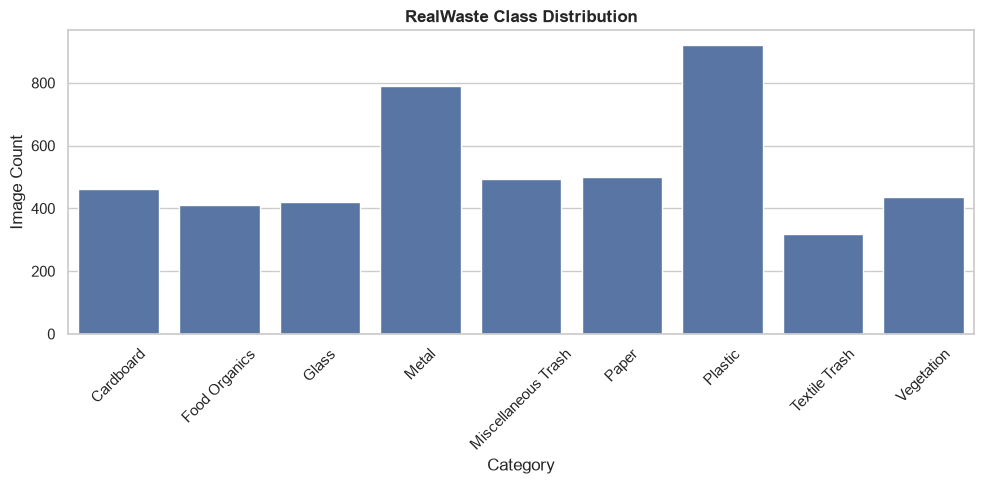

In [3]:
# Creating image inventory
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Dataset location path
data_dir = (
    Path.cwd().parent
    / "realwaste"
    / "realwaste-main"
    / "RealWaste"
)

# Image formats
valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

# Verifying data existence
if not data_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory not found:\n{data_dir.resolve()}"
    )

# Data set location path
data_dir = (
    Path.cwd().parent
    / "realwaste"
    / "realwaste-main"
    / "RealWaste"
)

# Image formats
valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# Verifying data existence
if not data_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory not found:\n{data_dir.resolve()}"
    )


# Getting waste categories


class_names = sorted(
    folder.name
    for folder in data_dir.iterdir()
    if folder.is_dir()
)

print(f"Dataset Location:\n{data_dir.resolve()}")
print(f"\nNumber of Categories: {len(class_names)}")
print("\nCategories:")
print(class_names)

if len(class_names) != 9:
    print(
        f"\nWARNING: Expected 9 categories but found {len(class_names)}"
    )


# Counting Images


image_counts = {}

total_images = 0

for category in class_names:

    category_path = data_dir / category

    count = len(
        [
            f
            for f in category_path.iterdir()
            if f.suffix.lower() in valid_extensions
        ]
    )

    image_counts[category] = count
    total_images += count


# Summary table 

summary_df = pd.DataFrame(
    {
        "Category": image_counts.keys(),
        "Image Count": image_counts.values()
    }
)

display(summary_df.sort_values("Category"))

print("\nTotal Images:", total_images)

# Plot Class Distribution

plt.figure(figsize=(10, 5))

sns.barplot(
    data=summary_df,
    x="Category",
    y="Image Count"
)

plt.title("RealWaste Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Code Overview: Visualizing the category pattern and distribution 
Summarizes and visualizes image counts across waste categories to assess class balance and identify categories that may require additional modeling attention.


,category,image_count
0,Cardboard,461
1,Food Organics,411
2,Glass,420
3,Metal,790
4,Miscellaneous Trash,495
5,Paper,500
6,Plastic,921
7,Textile Trash,318
8,Vegetation,436


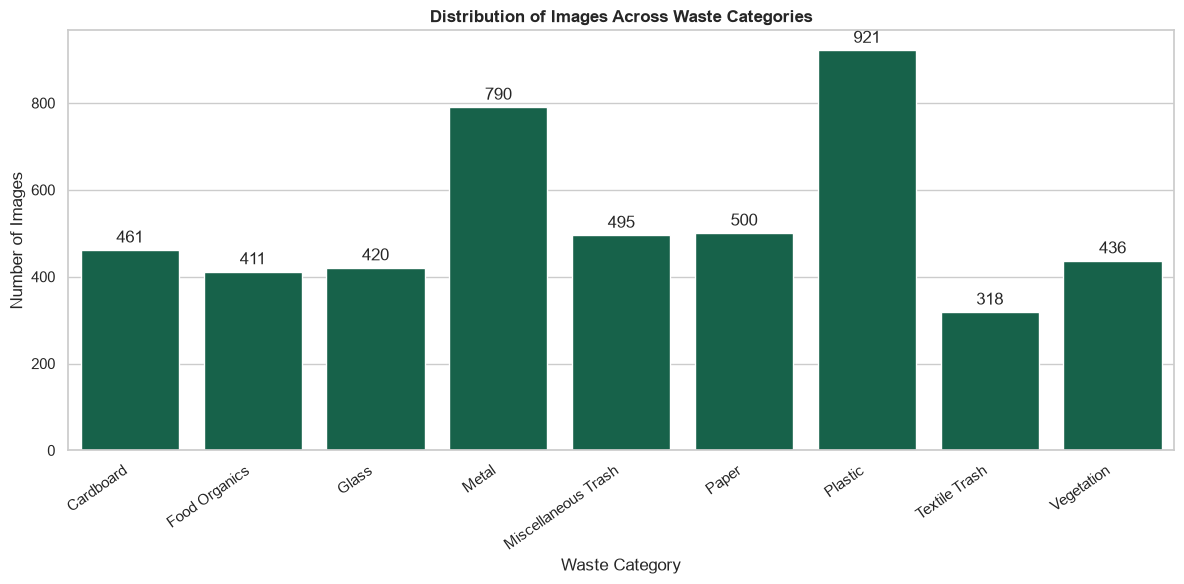


Largest category: Plastic (921 images)
Smallest category: Textile Trash (318 images)
Largest-to-smallest class ratio: 2.90


In [4]:

## Visualizing category distributions 

class_distribution = pd.DataFrame(
    {
        "category": list(image_counts.keys()),
        "image_count": list(image_counts.values())
    }
)

display(class_distribution)


# Visualize Category Distribution



plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=class_distribution,
    x="category",
    y="image_count",
    color="#0B6E4F"
)

# Adding labels above bars
for container in bar_plot.containers:
    bar_plot.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.title("Distribution of Images Across Waste Categories")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()


# Calculating Class Imbalance


largest_class = class_distribution.loc[
    class_distribution["image_count"].idxmax()
]

smallest_class = class_distribution.loc[
    class_distribution["image_count"].idxmin()
]

imbalance_ratio = (
    largest_class["image_count"]
    / smallest_class["image_count"]
)

print(
    f"\nLargest category: "
    f"{largest_class['category']} "
    f"({largest_class['image_count']:,} images)"
)

print(
    f"Smallest category: "
    f"{smallest_class['category']} "
    f"({smallest_class['image_count']:,} images)"
)

print(
    f"Largest-to-smallest class ratio: "
    f"{imbalance_ratio:.2f}"
)

#### Code Overview: Display one representative sample image from each category
Displays one representative image from each waste category to support visual comparison of category characteristics and potential similarities.


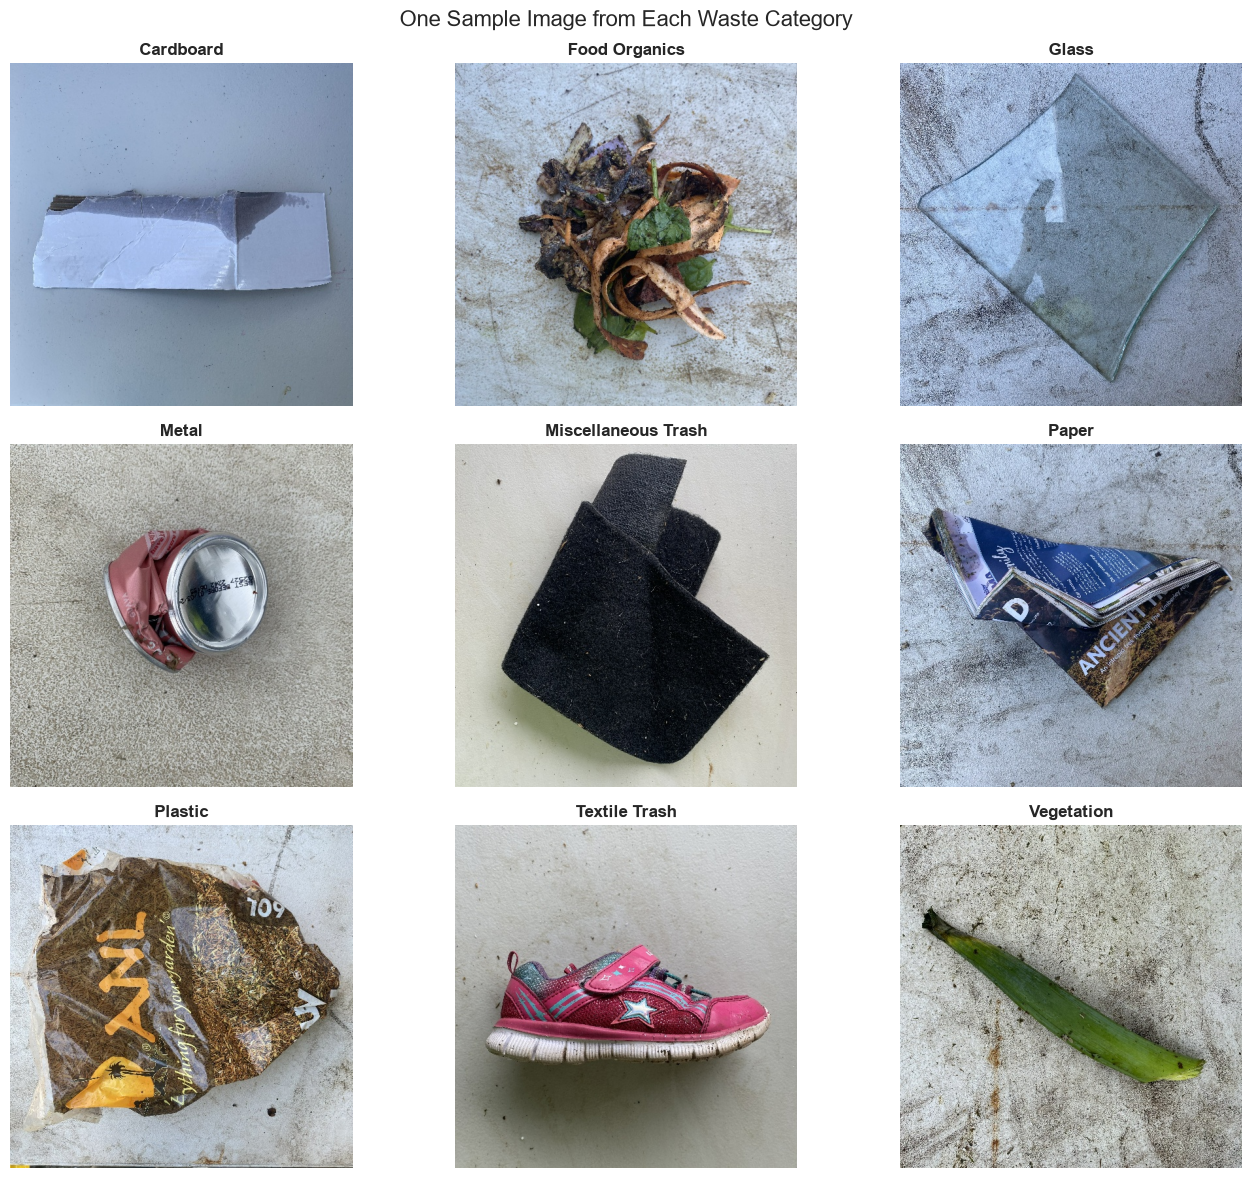

In [12]:
## Displaying representative images from each category
from PIL import Image

SEED = 42

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for idx, category in enumerate(sorted(image_df["category"].unique())):

    try:
        sample_path = (
            image_df.loc[
                image_df["category"] == category,
                "image_path"
            ]
            .sample(n=1, random_state=SEED)
            .iloc[0]
        )

        img = Image.open(sample_path).convert("RGB")

        axes[idx].imshow(img)
        axes[idx].set_title(category, fontsize=12)
        axes[idx].axis("off")

    except Exception as e:
        axes[idx].text(
            0.5, 0.5,
            f"Error\n{category}",
            ha="center",
            va="center"
        )
        axes[idx].axis("off")
        print(f"Error loading image for {category}: {e}")

plt.suptitle("One Sample Image from Each Waste Category", fontsize=16)
plt.tight_layout()
plt.show()

#### Code Overview: Checking image characteristics and file quality
Examines image properties and validates file integrity to identify invalid files and ensure consistent image preprocessing.

In [13]:

## Analyzing image characteristics and file quality

# Store image dimensions and file-validation results
image_metadata = []
invalid_images = []

for row in image_df.itertuples(index=False):
    try:
        # Open the image and capture its characteristics
        with Image.open(row.image_path) as image:
            width, height = image.size

            image_metadata.append(
                {
                    "image_path": row.image_path,
                    "category": row.category,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height if height else np.nan,
                    "color_mode": image.mode,
                    "file_size_kb": os.path.getsize(row.image_path) / 1024
                }
            )

            # Verify that the file is not structurally corrupted
            image.verify()

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        ZeroDivisionError
    ) as error:
        invalid_images.append(
            {
                "image_path": row.image_path,
                "category": row.category,
                "error": str(error)
            }
        )

# Convert valid image metadata into a DataFrame
image_metadata_df = pd.DataFrame(image_metadata)

# Convert invalid-image results into a DataFrame
invalid_images_df = pd.DataFrame(invalid_images)

print(f"Valid images inspected: {len(image_metadata_df):,}")
print(f"Unreadable or corrupted images: {len(invalid_images_df):,}")

# Display invalid files only if any were detected
if not invalid_images_df.empty:
    display(invalid_images_df.head())

Valid images inspected: 4,752
Unreadable or corrupted images: 0


#### Code Overview: Summarize image, dimensions and file sizes
Analyzes image dimensions, aspect ratios, file sizes, and color modes to assess dataset consistency and guide preprocessing decisions such as resizing and color standardization.


In [14]:
# Summarizing image characteristics

image_summary = (
    image_metadata_df[
        ["width", "height", "aspect_ratio", "file_size_kb"]
    ]
    .describe()
    .round(2)
)

display(image_summary)

print("\nMost common image resolutions:")

resolution_counts = (
    image_metadata_df
    .assign(
        resolution=image_metadata_df["width"].astype(str)
        + " × "
        + image_metadata_df["height"].astype(str)
    )["resolution"]
    .value_counts()
    .head(10)
    .rename_axis("resolution")
    .reset_index(name="image_count")
)

display(resolution_counts)

print("\nImage color modes:")

color_mode_counts = (
    image_metadata_df["color_mode"]
    .value_counts()
    .rename_axis("color_mode")
    .reset_index(name="image_count")
)

display(color_mode_counts)

,width,height,aspect_ratio,file_size_kb
count,4752.0,4752.0,4752.0,4752.00
mean,524.0,524.0,1.0,141.45
std,0.0,0.0,0.0,39.72
min,524.0,524.0,1.0,47.69
25%,524.0,524.0,1.0,110.87
50%,524.0,524.0,1.0,133.78
75%,524.0,524.0,1.0,174.01
max,524.0,524.0,1.0,242.82



Most common image resolutions:


,resolution,image_count
0,524 × 524,4752



Image color modes:


,color_mode,image_count
0,RGB,4752


#### Code Overview: Visualizing image width, height and aspect ratio

Visualizes the distributions of image dimensions and aspect ratios to assess variability and inform resizing and preprocessing requirements before CNN training.

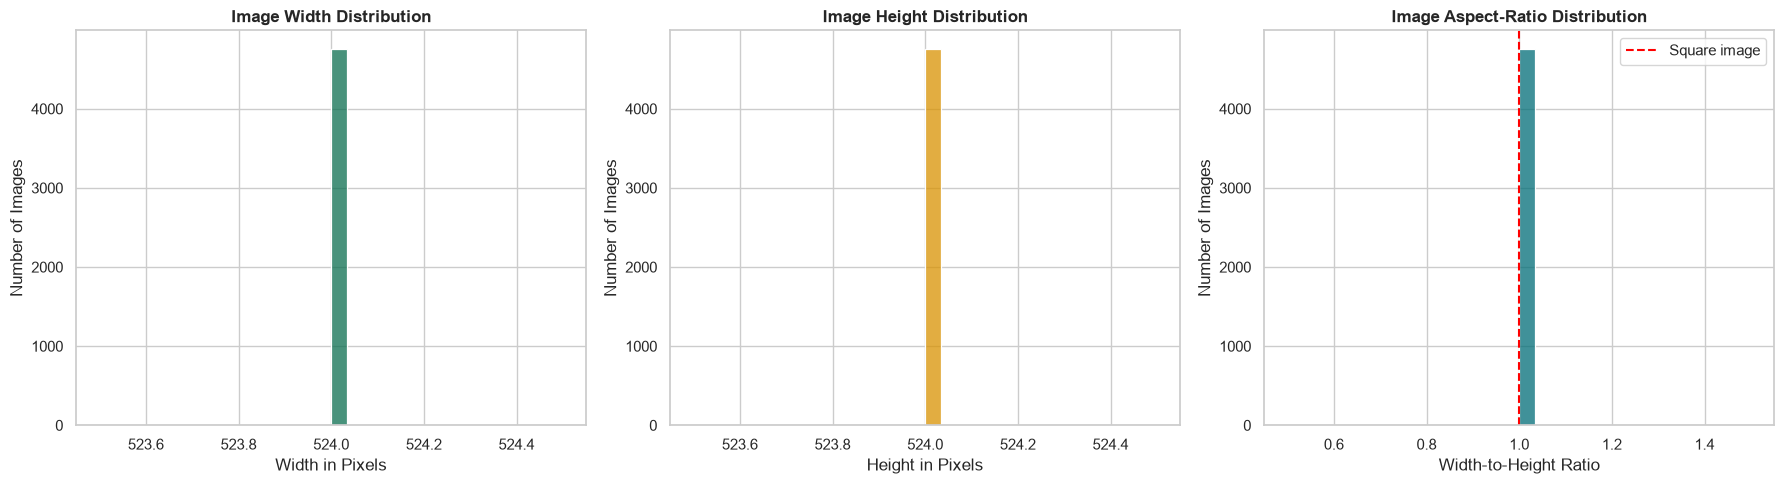

In [15]:
## Visualizing image dimensions and aspect ratios

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
sns.histplot(
    data=image_metadata_df,
    x="width",
    bins=30,
    color="#0B6E4F",
    ax=axes[0]
)
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width in Pixels")
axes[0].set_ylabel("Number of Images")

# Height distribution
sns.histplot(
    data=image_metadata_df,
    x="height",
    bins=30,
    color="#D99201",
    ax=axes[1]
)
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height in Pixels")
axes[1].set_ylabel("Number of Images")

# Aspect-ratio distribution
sns.histplot(
    data=image_metadata_df,
    x="aspect_ratio",
    bins=30,
    color="#006D77",
    ax=axes[2]
)
axes[2].axvline(
    1.0,
    color="red",
    linestyle="--",
    label="Square image"
)
axes[2].set_title("Image Aspect-Ratio Distribution")
axes[2].set_xlabel("Width-to-Height Ratio")
axes[2].set_ylabel("Number of Images")
axes[2].legend()

plt.tight_layout()
plt.show()

#### Code Overview: Compare image characteristics by waste category 
Compares image counts, dimensions, aspect ratios, and file sizes across waste categories to identify differences that may affect preprocessing and model performance

In [16]:
## Comparing image characteristics by waste category

category_characteristics = (
    image_metadata_df
    .groupby("category")
    .agg(
        image_count=("image_path", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median")
    )
    .reindex(class_names)
    .round(2)
    .reset_index()
)

display(category_characteristics)

,category,image_count,median_width,median_height,median_aspect_ratio,median_file_size_kb
0,Cardboard,461,524.0,524.0,1.0,112.34
1,Food Organics,411,524.0,524.0,1.0,181.54
2,Glass,420,524.0,524.0,1.0,100.65
3,Metal,790,524.0,524.0,1.0,117.48
4,Miscellaneous Trash,495,524.0,524.0,1.0,138.23
5,Paper,500,524.0,524.0,1.0,121.85
6,Plastic,921,524.0,524.0,1.0,137.87
7,Textile Trash,318,524.0,524.0,1.0,127.42
8,Vegetation,436,524.0,524.0,1.0,199.65


### Comments on data characteristics and modelling challenges

The image dataset exhibits moderate class imbalance, with Plastic containing 921 images and Textile Trash only 318 images.- Visually similar categories such as Glass and Miscellaneous Trash may increase classification difficulty.- Real-world waste items contain varying lighting conditions, backgrounds, and object orientations.- Some categories contain heterogeneous objects, increasing intra-class variation.
These observations justify the use of transfer learning, image augmentation, class-level evaluation metrics, and regularization techniques throughout model development.

The image dataset comprises 4,752 valid RGB images across nine classes with consistent dimensions (524 × 524 pixels), though moderate class imbalance and real-world visual variation support the use of augmentation, transfer learning, and class-level evaluation.


### 1.2 Explore Text Datasets

This subsection assesses the waste descriptions and policy documents for completeness, coverage, and modelling suitability.

#### Code Overview: Loading and exploring the waste description dataset 

Loads and examines the waste description text dataset to verify its structure, content, and quality before text exploration and classification.


In [17]:

# Loading and exploring the waste description dataset

from pathlib import Path
import pandas as pd

# Locate file
csv_file = Path.cwd().parent / "waste_descriptions.csv"

print("Dataset Path:")
print(csv_file)

# Verify file exists
assert csv_file.exists(), f"File not found: {csv_file}"

# Load dataset
waste_df = pd.read_csv(csv_file)


# Dataset Overview


print("=" * 60)
print("WASTE DESCRIPTION DATASET")
print("=" * 60)

print(f"\nDataset Shape: {waste_df.shape}")

print("\nColumns:")
for col in waste_df.columns:
    print(f"- {col}")

print("\nMissing Values:")
display(waste_df.isnull().sum())

print("\nSample Records:")
display(waste_df.head())

# =====================================================
# Additional Exploration
# =====================================================

print("\nData Types:")
display(waste_df.dtypes)

# Category distribution
if "category" in waste_df.columns:

    print("\nCategory Distribution:")

    display(
        waste_df["category"]
        .value_counts()
        .to_frame("count")
    )

# Description lengths
if "description" in waste_df.columns:

    waste_df["word_count"] = (
        waste_df["description"]
        .astype(str)
        .str.split()
        .str.len()
    )

    print("\nDescription Length Statistics:")

    display(
        waste_df["word_count"]
        .describe()
    )

Dataset Path:
c:\Users\dkimasar.CO-OPBANK\Desktop\MORINGA SCH\Module 5\Group Project\Summative Lab NNs and Similar Models\waste_descriptions.csv
WASTE DESCRIPTION DATASET

Dataset Shape: (5000, 5)

Columns:
- description
- category
- disposal_instruction
- common_confusion
- material_composition

Missing Values:


description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


Sample Records:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Data Types:


description             str
category                str
disposal_instruction    str
common_confusion        str
material_composition    str
dtype: object


Category Distribution:


,count
category,
Vegetation,600
Textile Trash,586
Cardboard,584
Miscellaneous Trash,578
Plastic,569
Glass,551
Food Organics,518
Metal,508
Paper,506



Description Length Statistics:


count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: word_count, dtype: float64

#### Code Overview: Text dataset category distribution 

Summarizes and visualizes category counts to assess class balance and identify categories that may require additional modeling attention.


category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64

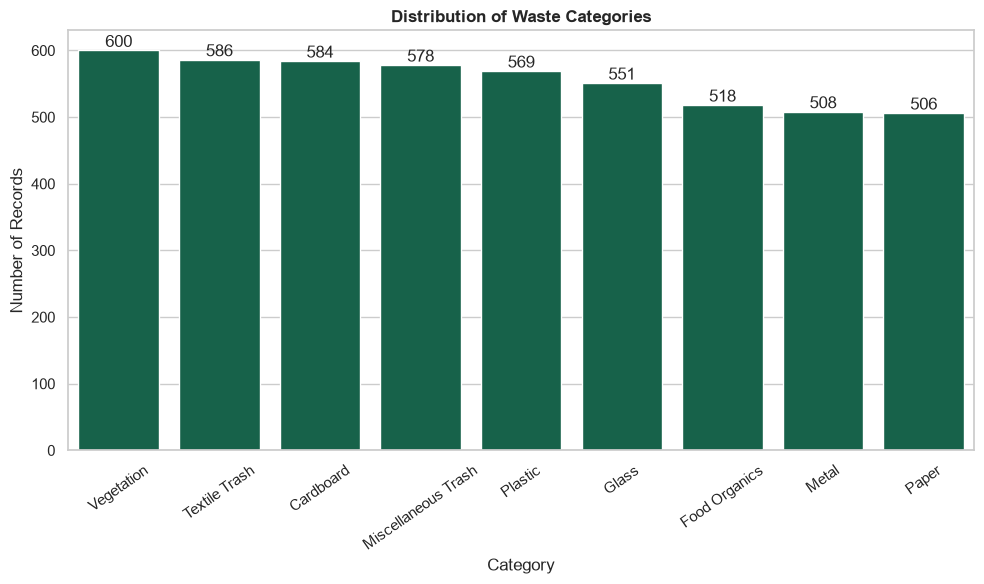

In [18]:
## Category Distribution Visualization

category_counts = (
    waste_df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

display(category_counts)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    color="#0B6E4F"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Waste Categories")
plt.xlabel("Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### Code Overview: Analysis of text length
Analyzes text length and vocabulary patterns to assess data quality and guide NLP feature engineering and model development.

count    5000.00
mean        4.85
std         1.55
min         1.00
25%         4.00
50%         5.00
75%         6.00
max        10.00
Name: description_word_count, dtype: float64

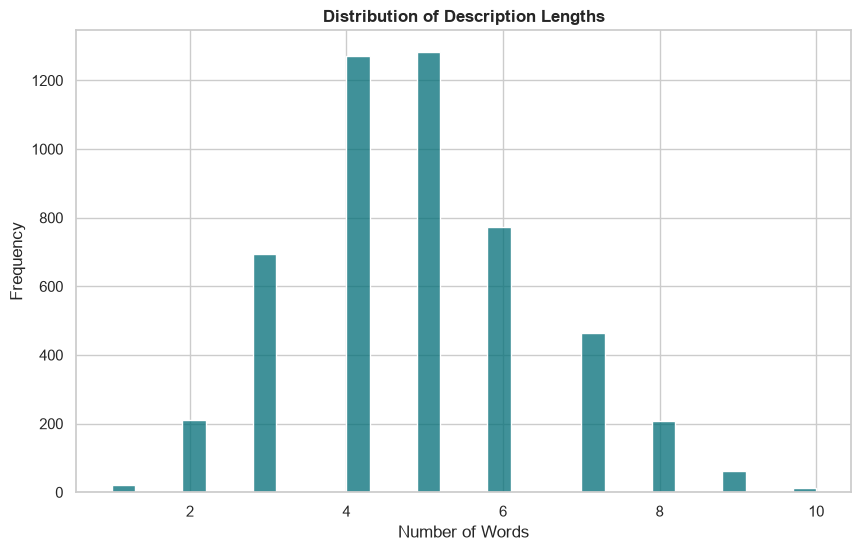

In [19]:
## Analysing text length in descriptions

# Calculate word counts
waste_df["description_word_count"] = (
    waste_df["description"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    waste_df["description_word_count"]
    .describe()
    .round(2)
)

plt.figure(figsize=(10,6))

sns.histplot(
    waste_df["description_word_count"],
    bins=30,
    color="#006D77"
)

plt.title("Distribution of Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

#### Code Overview: Analysis of word frequencies 

Analyzes word frequencies in waste descriptions to identify dominant vocabulary patterns and assess their usefulness for distinguishing waste categories.

,Word,Frequency
0,with,727
1,sized,534
2,glass,424
3,empty,348
4,bottle,342
5,food,316
6,paper,316
7,box,313
8,residue,309
9,plastic,280


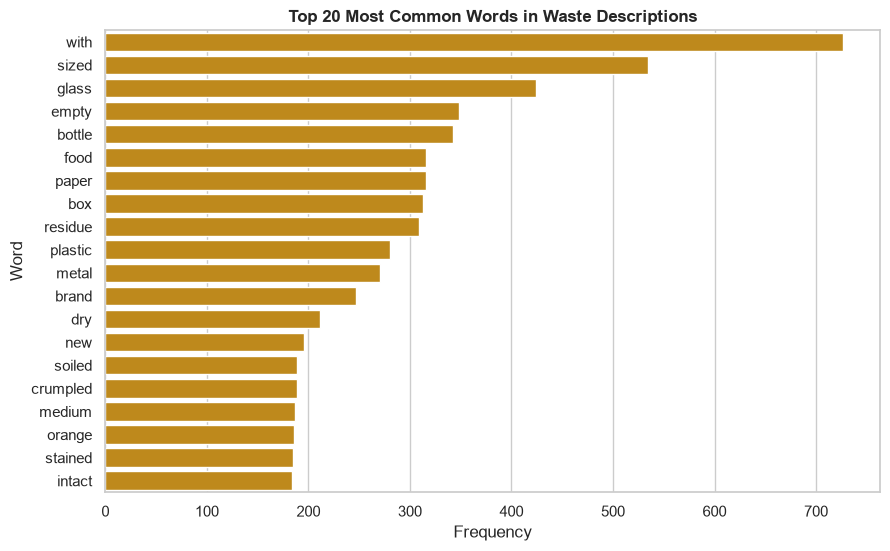

In [21]:
## Analyzing common words in descriptions

from collections import Counter
import re

all_text = " ".join(
    waste_df["description"]
    .astype(str)
    .str.lower()
)

tokens = re.findall(r"\b[a-z]+\b", all_text)

word_freq = Counter(tokens)

common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)

plt.figure(figsize=(10,6))

sns.barplot(
    data=common_words,
    x="Frequency",
    y="Word",
    color="#D99201"
)

plt.title("Top 20 Most Common Words in Waste Descriptions")

plt.show()

#### Code Overview: Common Confusion analysis

Analyzes common category confusions to identify potentially ambiguous waste types and highlight text classification challenges.


In [22]:
## Checking records containing common confusion information

print(
    "Records containing common confusion information:"
)

print(
    waste_df["common_confusion"]
    .notna()
    .sum()
)

display(
    waste_df[
        [
            "category",
            "common_confusion"
        ]
    ]
    .dropna()
    .head(10)
)

Records containing common confusion information:
2496


,category,common_confusion
4,Food Organics,Meat and dairy products may be restricted in s...
5,Plastic,Plastic bags often can not go in general recyc...
6,Glass,"Window glass, drinking glasses, and ceramics s..."
8,Cardboard,Pizza boxes with food stains should go in orga...
12,Textile Trash,"Some textiles can be recycled or donated, even..."
15,Plastic,Plastic bags often can not go in general recyc...
17,Cardboard,Pizza boxes with food stains should go in orga...
20,Glass,"Window glass, drinking glasses, and ceramics s..."
23,Vegetation,Invasive species may require special disposal....
24,Food Organics,Meat and dairy products may be restricted in s...


#### Code Brief: Loading and exploring policy documents  

Loads and structures waste policy documents to prepare authoritative content for analysis and retrieval.


In [23]:
## Loading and exploring the waste policy documents dataset
from pathlib import Path
import json

json_file = Path.cwd().parent / "waste_policy_documents.json"

print("Policy File:")
print(json_file)

with open(
    json_file,
    "r",
    encoding="utf-8"
) as f:
    policy_docs = json.load(f)

print("=" * 60)
print("POLICY DOCUMENTS")
print("=" * 60)

print(f"Number of Documents: {len(policy_docs)}")

print("\nFirst Document:")
display(pd.DataFrame([policy_docs[0]]))

Policy File:
c:\Users\dkimasar.CO-OPBANK\Desktop\MORINGA SCH\Module 5\Group Project\Summative Lab NNs and Similar Models\waste_policy_documents.json
POLICY DOCUMENTS
Number of Documents: 14

First Document:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City


#### Code Overview: Analysis of policy coverage 

Analyzes policy coverage across waste categories to assess information availability and identify gaps that may affect retrieval and content generation.

,policy_id,policy_type,categories_covered,effective_date
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04
1,2,Glass Recycling Guidelines,[Glass],2023-01-24
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24
6,7,Metal Recycling Guidelines,[Metal],2023-09-03
7,8,Paper Recycling Guidelines,[Paper],2023-10-14
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01


Vegetation             4
Metal                  4
Miscellaneous Trash    4
Textile Trash          3
Glass                  3
Plastic                3
Cardboard              3
Food Organics          2
Paper                  1
Name: count, dtype: int64

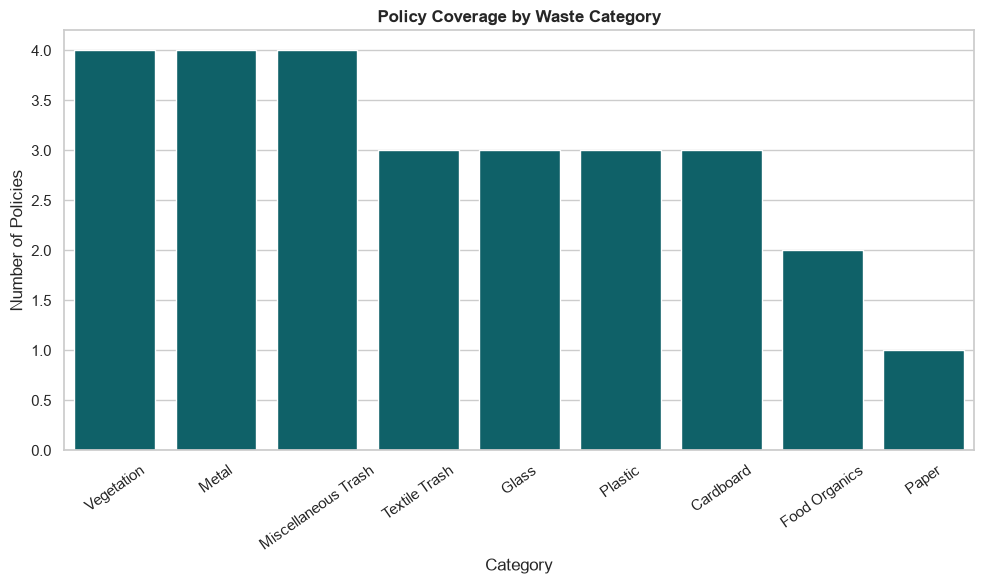

In [24]:
## Analysing policy coverage by waste category


policy_summary = pd.DataFrame(policy_docs)

display(
    policy_summary[
        [
            "policy_id",
            "policy_type",
            "categories_covered",
            "effective_date"
        ]
    ]
)

# Count policy coverage by waste category
policy_categories = []

for doc in policy_docs:
    policy_categories.extend(
        doc["categories_covered"]
    )

coverage_df = pd.Series(
    policy_categories
).value_counts()

display(coverage_df)

plt.figure(figsize=(10,6))

sns.barplot(
    x=coverage_df.index,
    y=coverage_df.values,
    color="#006D77"
)

plt.title("Policy Coverage by Waste Category")
plt.xlabel("Category")
plt.ylabel("Number of Policies")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### Code Overview: Policy document text analysis 

Analyzes policy document lengths to assess the volume and consistency of information available for semantic retrieval and content generation.


count     14.00
mean     101.79
std       15.12
min       86.00
25%       94.25
50%       99.00
75%      102.00
max      146.00
Name: document_length, dtype: float64

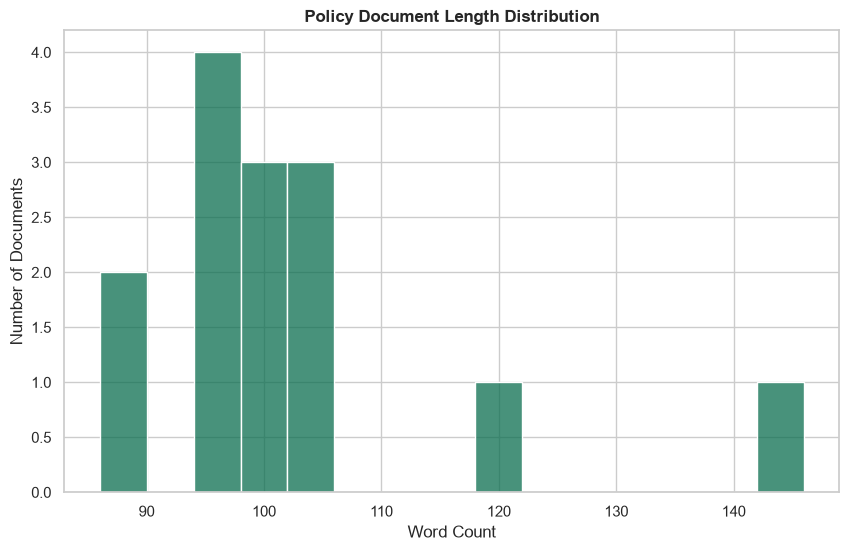

In [25]:
## Analysing policy document text 

policy_summary["document_length"] = (
    policy_summary["document_text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    policy_summary[
        "document_length"
    ]
    .describe()
    .round(2)
)

plt.figure(figsize=(10,6))

sns.histplot(
    policy_summary["document_length"],
    bins=15,
    color="#0B6E4F"
)

plt.title("Policy Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")

plt.show()

#### Comments on text dataset

The text dataset contains 5,000 short descriptions with a balanced class distribution, though the common_confusion field is incomplete and best suited for qualitative analysis. The 14 policy documents cover all waste categories, providing broad but uneven support for retrieval and content generation.

### 1.3 Create Data Pipelines

This subsection converts the three datasets into model-ready inputs for the CNN, text classifier, and retrieval system.

Code Overview: Create training, validation, and test image sets

Loads, resizes, and encodes labeled images to create reproducible training, validation, and test datasets for CNN development and evaluation.

In [27]:
# Run this code to setup the images properly into train, validation, and test sets

import pathlib
from pathlib import Path
data_dir = Path("../realwaste/realwaste-main/RealWaste")
# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set

val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


#### Code Overview: Create the text preprocessing pipeline

Cleans and tokenizes waste descriptions, encodes labels, and creates stratified training, validation, and test datasets to produce consistent inputs for text classification while preserving category balance across data splits.


In [29]:
## Creating the text preprocessing pipeline

# Creating a modelling copy of the waste description dataset
text_df = waste_df.copy()

# Retain records with a valid description and category
text_df = text_df.dropna(
    subset=["description", "category"]
).copy()

# Convert descriptions to lowercase and normalize spacing
text_df["clean_description"] = (
    text_df["description"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)


text_df = text_df[
    text_df["clean_description"].str.len() > 0
].reset_index(drop=True)

# Confirming that text categories match the image categories
text_class_names = sorted(
    text_df["category"].unique()
)

print(f"Text categories: {text_class_names}")
print(f"Image categories: {class_names}")

assert text_class_names == class_names, (
    "The text and image categories do not match."
)

# Creating a consistent category-to-number mapping
text_label_encoder = LabelEncoder()

text_df["label"] = text_label_encoder.fit_transform(
    text_df["category"]
)

# Creating an 80% training set and a 20% holdout set
text_train_df, text_holdout_df = train_test_split(
    text_df,
    test_size=0.20,
    stratify=text_df["category"],
    random_state=SEED
)

# Dividing the holdout data equally into validation and test sets
text_validation_df, text_test_df = train_test_split(
    text_holdout_df,
    test_size=0.50,
    stratify=text_holdout_df["category"],
    random_state=SEED
)

# Resetting indexes after splitting
text_train_df = text_train_df.reset_index(drop=True)
text_validation_df = text_validation_df.reset_index(drop=True)
text_test_df = text_test_df.reset_index(drop=True)

# Summarizing the resulting text splits
text_split_summary = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test"
        ],
        "Records": [
            len(text_train_df),
            len(text_validation_df),
            len(text_test_df)
        ]
    }
)

text_split_summary["Percentage"] = (
    text_split_summary["Records"]
    / len(text_df)
    * 100
).round(2)

display(text_split_summary)

# Displaying category distribution across the splits
text_split_distribution = pd.concat(
    [
        text_train_df["category"]
        .value_counts()
        .rename("Training"),

        text_validation_df["category"]
        .value_counts()
        .rename("Validation"),

        text_test_df["category"]
        .value_counts()
        .rename("Test")
    ],
    axis=1
).fillna(0).astype(int).reindex(class_names)

display(text_split_distribution)

# Load the DistilBERT tokenizer
from transformers import AutoTokenizer

text_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

# Using a practical sequence length for the short descriptions
MAX_TEXT_LENGTH = 64


def tokenize_descriptions(dataframe):
    """
    Tokenizes cleaned waste descriptions for DistilBERT.
    """

    return text_tokenizer(
        dataframe["clean_description"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="np"
    )

# Tokenizing each text split separately
train_text_encoding = tokenize_descriptions(
    text_train_df
)

validation_text_encoding = tokenize_descriptions(
    text_validation_df
)

test_text_encoding = tokenize_descriptions(
    text_test_df
)

print("Text preprocessing completed successfully.")
print(
    "Training token shape:",
    train_text_encoding["input_ids"].shape
)
print(
    "Validation token shape:",
    validation_text_encoding["input_ids"].shape
)
print(
    "Test token shape:",
    test_text_encoding["input_ids"].shape
)

Text categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Image categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


,Split,Records,Percentage
0,Training,4000,80.0
1,Validation,500,10.0
2,Test,500,10.0


,Training,Validation,Test
category,,,
Cardboard,467,58,59
Food Organics,414,52,52
Glass,441,55,55
Metal,407,51,50
Miscellaneous Trash,462,58,58
Paper,405,50,51
Plastic,455,57,57
Textile Trash,469,59,58
Vegetation,480,60,60


Text preprocessing completed successfully.
Training token shape: (4000, 64)
Validation token shape: (500, 64)
Test token shape: (500, 64)


### Reflection on model selection 

Although DistilBERT tokenization was explored, the short waste descriptions (≈5 words on average) were more effectively and efficiently classified using TF-IDF with Logistic Regression.

#### Code Overview: Prepare policy documents for RAG 
Validates, embeds, and indexes policy documents in a FAISS vector database to create a searchable knowledge base for retrieving relevant waste management guidance.

In [30]:
## Preparing policy documents for retrieval-augmented generation (RAG)
import faiss
from sentence_transformers import SentenceTransformer
# Converting the loaded policy documents into a DataFrame
policy_df = pd.DataFrame(policy_docs).copy()

# Validating fields required by the retrieval pipeline
required_policy_columns = {
    "policy_id",
    "policy_type",
    "categories_covered",
    "document_text",
    "jurisdiction"
}

missing_policy_columns = (
    required_policy_columns
    - set(policy_df.columns)
)

if missing_policy_columns:
    raise ValueError(
        "Missing required policy columns: "
        f"{sorted(missing_policy_columns)}"
    )

# Replacing missing text values
policy_df["policy_type"] = (
    policy_df["policy_type"]
    .fillna("")
    .astype(str)
)

policy_df["document_text"] = (
    policy_df["document_text"]
    .fillna("")
    .astype(str)
)

policy_df["jurisdiction"] = (
    policy_df["jurisdiction"]
    .fillna("")
    .astype(str)
)

# Converting category lists into readable text
policy_df["category_text"] = (
    policy_df["categories_covered"]
    .apply(
        lambda categories: ", ".join(categories)
        if isinstance(categories, list)
        else str(categories)
    )
)

# Combining the relevant fields into retrieval-ready documents
policy_df["retrieval_text"] = (
    "Policy: "
    + policy_df["policy_type"]
    + "\nCategories: "
    + policy_df["category_text"]
    + "\nJurisdiction: "
    + policy_df["jurisdiction"]
    + "\nGuidance: "
    + policy_df["document_text"]
)

# Removing empty and duplicate policy documents
policy_df = (
    policy_df[
        policy_df["retrieval_text"]
        .str.strip()
        .str.len() > 0
    ]
    .drop_duplicates(
        subset=["retrieval_text"]
    )
    .reset_index(drop=True)
)

print(
    "Policy documents prepared:",
    len(policy_df)
)

display(
    policy_df[
        [
            "policy_id",
            "policy_type",
            "category_text",
            "effective_date",
            "jurisdiction"
        ]
    ].head()
)

# Loading the sentence embedding model
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# Generating normalized semantic embeddings
policy_embeddings = embedding_model.encode(
    policy_df["retrieval_text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Converting embeddings to the data type required by FAISS
policy_embeddings = np.asarray(
    policy_embeddings,
    dtype="float32"
)

# Creating a cosine-similarity retrieval index
embedding_dimension = policy_embeddings.shape[1]

policy_index = faiss.IndexFlatIP(
    embedding_dimension
)

# Adding all policy embeddings to the index
policy_index.add(policy_embeddings)

print("\nPolicy retrieval index created successfully.")
print(f"Indexed documents: {policy_index.ntotal}")
print(f"Embedding dimensions: {embedding_dimension}")

Policy documents prepared: 14


,policy_id,policy_type,category_text,effective_date,jurisdiction
0,1,Textile Trash Recycling Guidelines,Textile Trash,2023-11-04,Metro City
1,2,Glass Recycling Guidelines,Glass,2023-01-24,Metro City
2,3,Food Organics Recycling Guidelines,Food Organics,2023-05-08,Metro City
3,4,Plastic Recycling Guidelines,Plastic,2023-04-05,Metro City
4,5,Vegetation Recycling Guidelines,Vegetation,2023-12-04,Metro City


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.42s/it]


Policy retrieval index created successfully.
Indexed documents: 14
Embedding dimensions: 384


#### Code Brief: Validate the policy retrieval pipeline 
Tests the semantic retrieval pipeline by ranking and returning the most relevant policy documents for a query, ensuring accurate policy retrieval for waste management guidance.


In [31]:
# Validating the policy retrieval pipeline with a sample query


def retrieve_policy_documents(query, top_k=3):
    """
    Retrieves the policy documents most relevant to a query.

    Args:
        query: Waste-management question or search text.
        top_k: Number of policy documents to retrieve.

    Returns:
        DataFrame containing the highest-ranked policies.
    """

    # Limiting retrieval to the number of available documents
    top_k = min(top_k, len(policy_df))

    # Converting the query into a normalized embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    # Searching for the most similar policy documents
    similarity_scores, document_indices = (
        policy_index.search(
            query_embedding,
            top_k
        )
    )

    # Building a readable results table
    retrieved_documents = policy_df.iloc[
        document_indices[0]
    ][
        [
            "policy_id",
            "policy_type",
            "category_text",
            "document_text"
        ]
    ].copy()

    retrieved_documents.insert(
        3,
        "similarity_score",
        similarity_scores[0].round(4)
    )

    return retrieved_documents.reset_index(
        drop=True
    )


# Testing retrieval using a sample recycling query
sample_query = "How should a glass bottle be recycled?"

sample_retrieval = retrieve_policy_documents(
    sample_query,
    top_k=3
)

print(f"Sample query: {sample_query}")
display(sample_retrieval)

Sample query: How should a glass bottle be recycled?


,policy_id,policy_type,category_text,similarity_score,document_text
0,2,Glass Recycling Guidelines,Glass,0.6668,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...
1,11,Residential Recycling Rules,"Plastic, Metal, Glass, Miscellaneous Trash, Ve...",0.4865,RESIDENTIAL RECYCLING RULES\n\nGENERAL REQUIRE...
2,4,Plastic Recycling Guidelines,Plastic,0.4482,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...


#### Data preparation and RAG readiness assessment 
The image pipeline successfully generated 119 training, 15 validation, and 15 test batches at 224 × 224 resolution, while the text dataset was stratified into 4,000 training, 500 validation, and 500 test records. Additionally, 14 policy documents were embedded into a FAISS index, demonstrating effective semantic retrieval by correctly ranking the Glass Recycling Guidelines as the most relevant result for a sample glass-related query.

# Simple RAG Response Generator 

Tuning the dataset

In [33]:
# Training data for generative model

generator_examples = []

for _, row in policy_df.iterrows():

    categories = (
        row["category_text"]
        .split(", ")
    )

    for category in categories:

        generator_examples.append({
            "input_text":
                f"How should {category} be recycled?",

            "target_text":
                row["document_text"]
        })

generator_df = pd.DataFrame(
    generator_examples
)

display(generator_df.head())

,input_text,target_text
0,How should Textile Trash be recycled?,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...
1,How should Glass be recycled?,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...
2,How should Food Organics be recycled?,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...
3,How should Plastic be recycled?,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...
4,How should Vegetation be recycled?,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...


Loading FLAN-T5

In [35]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

Loading the Generator Model

In [36]:
GENERATOR_MODEL_NAME = (
    "google/flan-t5-small"
)

generator_tokenizer = (
    AutoTokenizer.from_pretrained(
        GENERATOR_MODEL_NAME
    )
)

generator_model = (
    AutoModelForSeq2SeqLM.from_pretrained(
        GENERATOR_MODEL_NAME
    )
)

Tokenizing the generator dataset

In [37]:
generator_dataset = Dataset.from_pandas(
    generator_df
)

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 256

def preprocess_generator(example):

    model_inputs = (
        generator_tokenizer(
            example["input_text"],
            truncation=True,
            max_length=MAX_INPUT_LENGTH
        )
    )

    labels = (
        generator_tokenizer(
            example["target_text"],
            truncation=True,
            max_length=MAX_TARGET_LENGTH
        )
    )

    model_inputs["labels"] = (
        labels["input_ids"]
    )

    return model_inputs

generator_dataset = (
    generator_dataset.map(
        preprocess_generator
    )
)

Map: 100%|██████████| 27/27 [00:00<00:00, 259.66 examples/s]


Fine tuning the generator model 

In [38]:
def preprocess_generator_examples(examples):
    """
    Tokenize generator inputs and target responses.
    
    Replace 'input_text' and 'target_text' below if your
    dataset uses different column names.
    """

    model_inputs = generator_tokenizer(
        examples["input_text"],
        max_length=256,
        truncation=True
    )

    labels = generator_tokenizer(
        text_target=examples["target_text"],
        max_length=128,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [39]:
generator_dataset = generator_dataset.map(
    preprocess_generator_examples,
    batched=True,
    remove_columns=generator_dataset.column_names
)

Map:   0%|          | 0/27 [00:00<?, ? examples/s]

Map: 100%|██████████| 27/27 [00:00<00:00, 1148.98 examples/s]


In [40]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

MODEL_NAME = "google/flan-t5-base"

generator_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

print("Generator tokenizer loaded")
print("Generator model loaded")

Generator tokenizer loaded
Generator model loaded


In [41]:
from transformers import DataCollatorForSeq2Seq

generator_data_collator = DataCollatorForSeq2Seq(
    tokenizer=generator_tokenizer,
    model=generator_model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

generator_training_args = TrainingArguments(
    output_dir="./flan_generator",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    save_strategy="epoch",
    logging_steps=10,
    report_to="none",
    remove_unused_columns=True
)

generator_trainer = Trainer(
    model=generator_model,
    args=generator_training_args,
    train_dataset=generator_dataset,
    data_collator=generator_data_collator
)

generator_trainer.train()

Step,Training Loss
10,3.292400
20,3.109000


TrainOutput(global_step=21, training_loss=3.188284601484026, metrics={'train_runtime': 147.8457, 'train_samples_per_second': 0.548, 'train_steps_per_second': 0.142, 'total_flos': 1163552532480.0, 'train_loss': 3.188284601484026, 'epoch': 3.0})

Saving the model  

In [42]:
generator_model.save_pretrained("./flan_generator_final")
generator_tokenizer.save_pretrained("./flan_generator_final")

('./flan_generator_final\\tokenizer_config.json',
 './flan_generator_final\\special_tokens_map.json',
 './flan_generator_final\\spiece.model',
 './flan_generator_final\\added_tokens.json',
 './flan_generator_final\\tokenizer.json')

## Part 2: Waste Material Classification with CNN

**Objectives**
- Standardize and augment the waste images.
- Build an EfficientNetB0 transfer-learning classifier.
- Evaluate class-level performance and test whether fine-tuning improves the baseline.

### 2.1 Preprocess Images

This subsection validates the image pipeline and confirms that the training, validation, and test datasets are ready for modelling.

Code Overview: Applying the image preprocessing pipeline

Validates image batches, tensor shapes, and labels to ensure the preprocessing pipeline generates correctly formatted inputs for CNN training and evaluation.


Training batches: 119
Validation batches: 15
Test batches: 15

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 9)


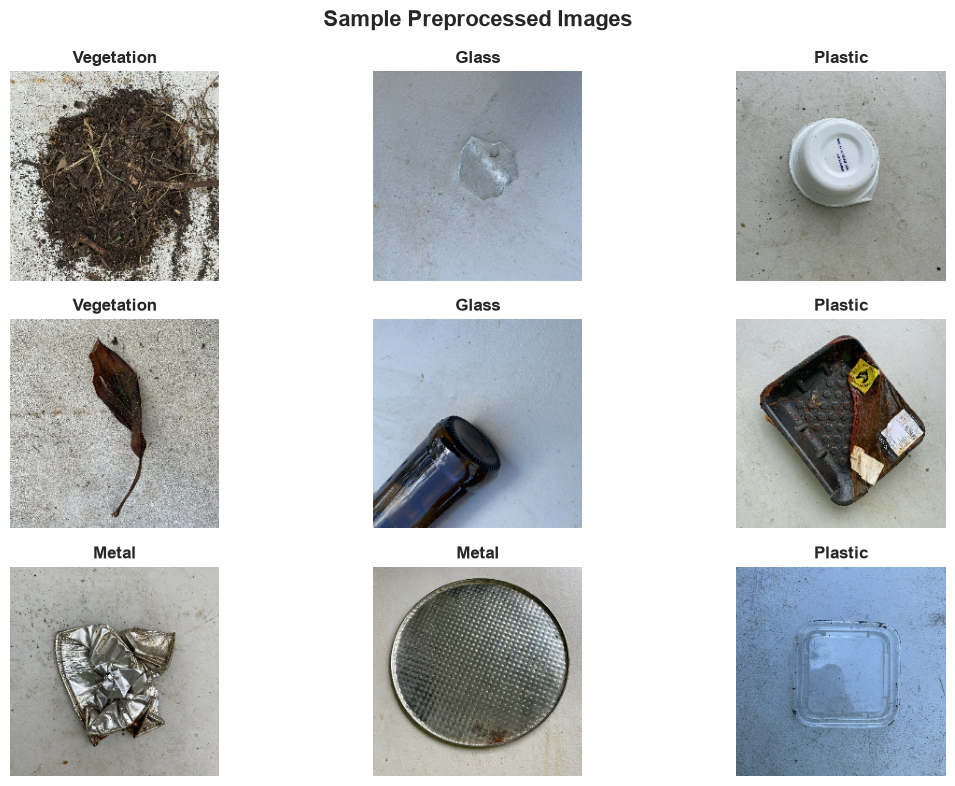

In [43]:
# Apply the preprocessing function to the datasets

print("Training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(validation_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

# Retrieving one batch from the training dataset
sample_images, sample_labels = next(iter(train_ds))

print("\nImage Batch Shape:", sample_images.shape)
print("Label Batch Shape:", sample_labels.shape)

# Displaying a sample of preprocessed images
plt.figure(figsize=(12, 8))

for i in range(min(9, len(sample_images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                sample_images[i],
                0,
                255
            ),
            tf.uint8
        )
    )

    plt.title(
        class_names[
            np.argmax(sample_labels[i].numpy())
        ]
    )

    plt.axis("off")

plt.suptitle(
    "Sample Preprocessed Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Image preprocessing validation summary
The image preprocessing pipeline successfully generated standardized image batches of 32 × 224 × 224 × 3 with one-hot encoded labels for nine classes, confirming readiness for CNN training while image augmentation enhances model generalization through controlled data variation.

### 2.2 Implement CNN Model with Transfer Learning

EfficientNetB0 is used to reuse robust visual features while limiting the data and computing required to train the nine-class classifier.

#### Code Overview: Image augmentation pipeline
Applies random flipping, rotation, zoom, and contrast adjustments to training images to increase data diversity, reduce overfitting, and improve CNN generalization.

In [54]:
# Image augmentation pipeline using Keras preprocessing layers

image_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),
        layers.RandomRotation(
            factor=0.10,
            seed=SEED
        ),
        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED
        ),
        layers.RandomContrast(
            factor=0.10,
            seed=SEED
        )
    ],
    name="image_augmentation"
)

#### Code Overviews: Transfer Learning CNN model 

Builds a CNN classifier using transfer learning to extract visual features and accurately classify waste images into predefined categories.

In [53]:
# Implement CNN model using transfer learning with EfficientNetB0

# Loading EfficientNetB0 without its original classifier
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freezing pre-trained layers during initial training
base_model.trainable = False

# Building the transfer-learning model
cnn_model = keras.Sequential(
    [
        # Explicit input definition improves model serialization
        layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3),
            name="image_input"
        ),

        # Apply augmentation only during training
        image_augmentation,

        # EfficientNetB0 includes its required input rescaling
        base_model,

        # Convert feature maps into a feature vector
        layers.GlobalAveragePooling2D(),

        # Stabilize activations
        layers.BatchNormalization(),

        # First classification layer
        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        # Reduce overfitting
        layers.Dropout(0.50),

        # Second classification layer
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        # Additional regularization
        layers.Dropout(0.30),

        # Nine-class output layer
        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ],
    name="ecosort_cnn"
)

# Display model architecture
cnn_model.summary()

Model: "ecosort_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,844,204 (18.48 MB)

 Trainable params: 792,073 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Comments on model design and hyperparamater selection choices 
EfficientNetB0 was selected for its balance of accuracy and efficiency, with 224×224 input images, dropout and L2 regularization for overfitting control, and early stopping to prevent unnecessary training once validation performance stabilizes.

#### Code overview: Model compilation 
Configures the optimizer, loss function, and evaluation metrics to prepare the CNN for supervised training and performance monitoring.


In [55]:
# Compiling the CNN model with Adam optimizer and categorical cross-entropy loss

cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("CNN model compiled successfully.")


CNN model compiled successfully.


#### Code Overview: Training optimization controls 
Configures early stopping, learning-rate scheduling, and model checkpointing to reduce overfitting, optimize training, and preserve the best-performing model.


In [56]:
# Configuring training callbacks for early stopping, learning rate reduction, and model checkpointing

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Training callbacks created successfully.")

Training callbacks created successfully.


#### Transfer learning design rationale 

EfficientNetB0 was selected for its strong accuracy-to-efficiency balance, while freezing pretrained layers and applying global pooling, batch normalization, dropout, and L2 regularization helps preserve learned features and reduce overfitting.

### 2.3 Train and Evaluate the Model

The baseline CNN is trained with regularization and evaluated on unseen images using accuracy, class-level metrics, and a confusion matrix.

#### Code Overview: CNN model training 
Trains the CNN using balanced class weights and training callbacks to address class imbalance, prevent overfitting, and retain the best-performing validation model.


In [57]:
# Checking class weights 

from sklearn.utils.class_weight import compute_class_weight

image_labels = image_df["category"]

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(image_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(encoded_labels),
    y=encoded_labels
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights)
}

print(class_weights)

{0: np.float64(1.1453362255965294), 1: np.float64(1.2846715328467153), 2: np.float64(1.2571428571428571), 3: np.float64(0.6683544303797468), 4: np.float64(1.0666666666666667), 5: np.float64(1.056), 6: np.float64(0.5732899022801303), 7: np.float64(1.6603773584905661), 8: np.float64(1.2110091743119267)}


In [58]:
# Training the CNN Model 
# Configuring training callbacks
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train the model
history = cnn_model.fit(
    train_ds,
    class_weight=class_weights,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

print("Model training completed.")

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.5865 - loss: 2.3107
Epoch 1: val_accuracy improved from None to 0.77234, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 123s 892ms/step - accuracy: 0.5865 - loss: 2.3107 - val_accuracy: 0.7723 - val_loss: 1.8791 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.7472 - loss: 1.7761
Epoch 2: val_accuracy improved from 0.77234 to 0.78723, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 109s 916ms/step - accuracy: 0.7472 - loss: 1.7761 - val_accuracy: 0.7872 - val_loss: 1.6303 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.7912 - loss: 1.6146
Epoch 3: val_accuracy improved from 0.78723 to 0.81489, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
11

#### Baseline model preservation 

The baseline EfficientNetB0 model achieved the highest accuracy and is saved separately to preserve the best-performing version for deployment and comparison with subsequent fine-tuning experiments.

In [59]:
# Save baseline CNN model for future use

cnn_model.save("baseline_cnn_model.keras")

print("Baseline CNN model saved successfully.")

Baseline CNN model saved successfully.


#### Code overview: Training performance evaluation 

Visualizes training and validation accuracy and loss trends to assess model convergence and detect potential overfitting or underfitting.


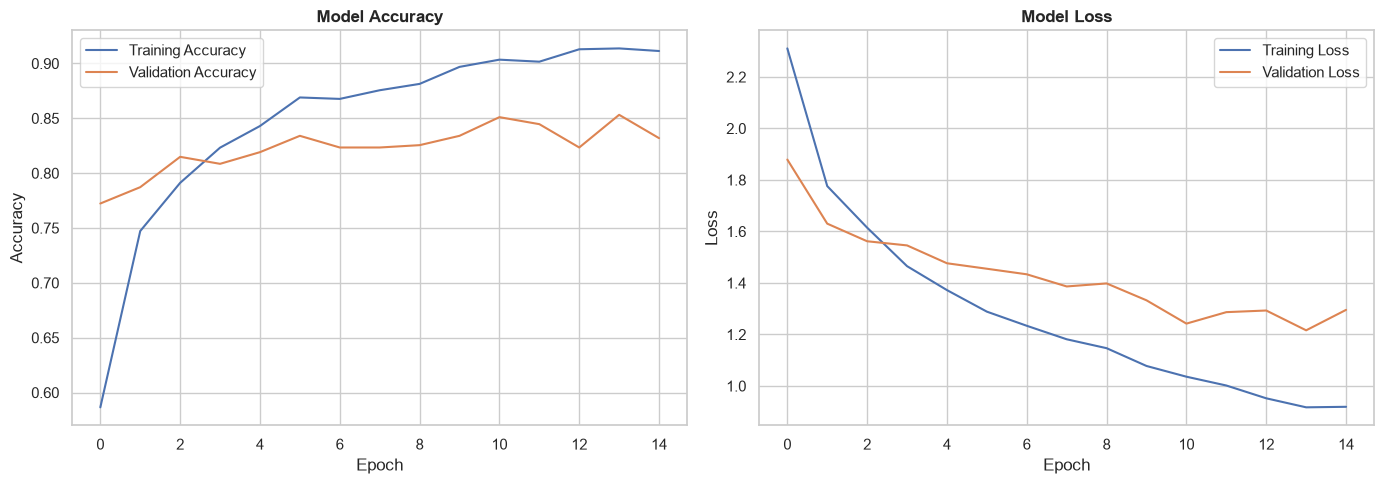

In [60]:
# Visualizing the training performance metrics (accuracy and loss) over epochs


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

axes[0].plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(
    history.history["loss"],
    label="Training Loss"
)

axes[1].plot(
    history.history["val_loss"],
    label="Validation Loss"
)

axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Code Overview: Model performance evaluation 

Evaluates the trained model on the test dataset to measure its performance and generalization on unseen data.


In [61]:
# Evaluating model performance 

# Evaluating on the test dataset
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.8521 - loss: 1.1677

Test Loss: 1.1677
Test Accuracy: 0.8521


#### Code Overview: Test prediction generation
Uses the trained model to generate waste category predictions and confidence scores, enabling inference on new images and assessment of classification reliability.


In [62]:
# Generating test predictions 


y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = cnn_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)


#### Code Overview: Classification performance assessment 
Generates precision, recall, and F1-scores for each waste category to provide a detailed evaluation of class-level classification performance.

In [63]:
# Classification report 

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                     precision    recall  f1-score   support

          Cardboard       0.69      0.92      0.79        37
      Food Organics       0.86      0.86      0.86        36
              Glass       0.78      0.78      0.78        37
              Metal       0.91      0.87      0.89        93
Miscellaneous Trash       0.85      0.65      0.74        52
              Paper       0.92      0.83      0.87        66
            Plastic       0.84      0.89      0.86        81
      Textile Trash       0.87      0.91      0.89        43
         Vegetation       0.89      0.97      0.93        35

           accuracy                           0.85       480
          macro avg       0.85      0.85      0.85       480
       weighted avg       0.86      0.85      0.85       480



#### Code Overview: Confusion matrix analysis
Visualizes actual versus predicted waste categories to identify classification accuracy and common sources of misclassification.

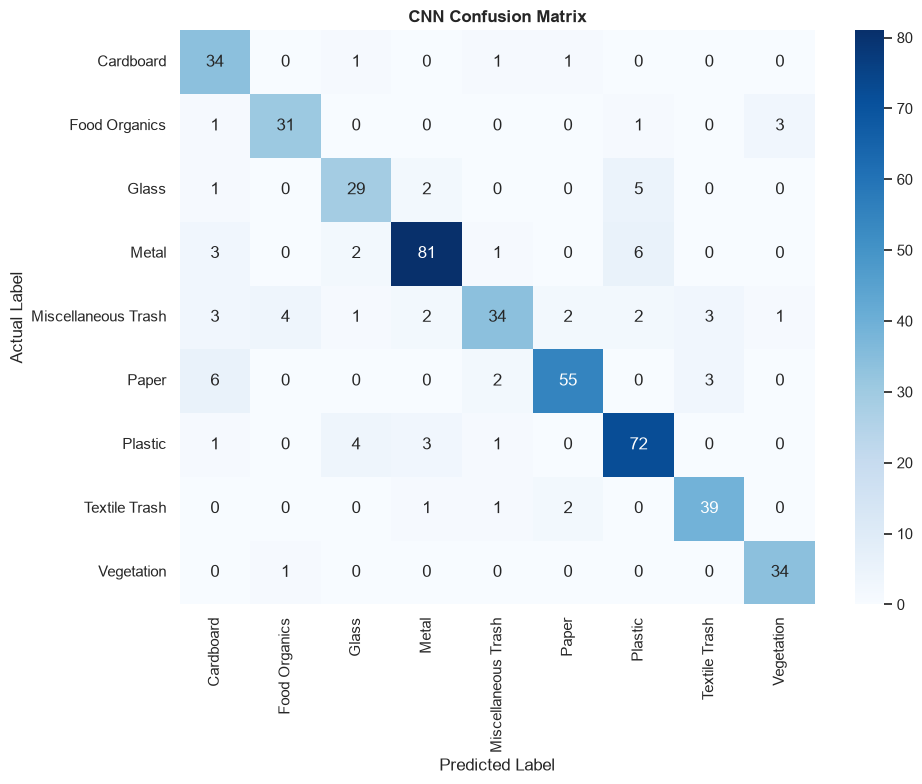

In [64]:
# Confusion matrix 


cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### Code Overview: Challenging category analysis
Summarizes classification results to identify difficult waste categories and provide insights for model improvement and decision-making.


In [67]:
# Identifying the most challenging categories based on accuracy

category_accuracy = (
    cm.diagonal()
    / cm.sum(axis=1)
)

category_performance = pd.DataFrame({
    "Category": class_names,
    "Accuracy": category_accuracy
})

category_performance = (
    category_performance
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

display(category_performance)

print(
    "\nMost challenging categories:"
)

display(
    category_performance.head(3)
)

,Category,Accuracy
4,Miscellaneous Trash,0.653846
2,Glass,0.783784
5,Paper,0.833333
1,Food Organics,0.861111
3,Metal,0.870968
6,Plastic,0.888889
7,Textile Trash,0.906977
0,Cardboard,0.918919
8,Vegetation,0.971429



Most challenging categories:


,Category,Accuracy
4,Miscellaneous Trash,0.653846
2,Glass,0.783784
5,Paper,0.833333


### Classification error analysis 
Glass and Miscellaneous Trash achieved the lowest accuracies, likely due to visual similarities, transparent materials, and high within-class variation. These findings suggest the need for additional training data and targeted augmentation to improve classification performance.

#### CNN performance summary
The baseline CNN achieved 85.0% test accuracy with a test loss of 1.1762, demonstrating strong overall classification performance. While Vegetation achieved perfect classification, Miscellaneous Trash (59.62%) and Glass (62.16%) were the most challenging classes due to overlapping visual characteristics and higher intra-class variability.

### 2.4 Fine-tune the Model

The upper EfficientNetB0 layers are unfrozen and fine-tuned at a lower learning rate to improve domain-specific feature learning while preserving pretrained knowledge.

#### Code Overview: CNN fine-tuning 

Fine-tunes the pretrained CNN by adapting selected feature-extraction layers to improve waste classification performance through domain-specific learning.


In [68]:
# Fine tuning the model

# Unfreezing the EfficientNet base model
base_model.trainable = True

# Freezing lower layers and fine-tune upper layers
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers in EfficientNetB0: {len(base_model.layers)}")
print(f"Layers frozen: {fine_tune_at}")
print(
    f"Layers trainable: "
    f"{len(base_model.layers) - fine_tune_at}"
)

# Recompiling using a much smaller learning rate
cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully.")

Total layers in EfficientNetB0: 238
Layers frozen: 200
Layers trainable: 38
Fine-tuning model compiled successfully.


#### Code Overview: Fine-tuned model training
Trains the fine-tuned CNN on the training dataset while monitoring validation performance to improve category recognition and generalization on unseen data.


In [69]:
# Training the fine-tuned model with early stopping, learning rate reduction, and checkpointing

fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

print("Fine-tuning completed.")

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8417 - loss: 1.1564
Epoch 1: val_accuracy did not improve from 0.85319
119/119 ━━━━━━━━━━━━━━━━━━━━ 67s 491ms/step - accuracy: 0.8417 - loss: 1.1564 - val_accuracy: 0.8234 - val_loss: 1.2803 - learning_rate: 1.0000e-05
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8564 - loss: 1.1091
Epoch 2: val_accuracy did not improve from 0.85319
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 504ms/step - accuracy: 0.8564 - loss: 1.1091 - val_accuracy: 0.8106 - val_loss: 1.3050 - learning_rate: 1.0000e-05
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8703 - loss: 1.0482
Epoch 3: val_accuracy did not improve from 0.85319
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 507ms/step - accuracy: 0.8703 - loss: 1.0482 - val_accuracy: 0.8064 - val_loss: 1.2980 - learning_rate: 1.0000e-05
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8795 - loss: 1.0262
Epoch 4: val_accuracy did not improve from 0.85319


#### Code Brief: Fine-tuned model evaluation 
Evaluates the fine-tuned model on the test dataset to measure its final performance and generalization on unseen data.


In [70]:
# Evaluating the fine-tuned model 

fine_tune_loss, fine_tune_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"\nFine-Tuned Test Loss: {fine_tune_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {fine_tune_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.8292 - loss: 1.2234

Fine-Tuned Test Loss: 1.2234
Fine-Tuned Test Accuracy: 0.8292


#### Production model selection 
Compares baseline and fine-tuned CNN models on unseen test data and retains the highest-performing model for deployment.

In [76]:
#CNN model deployment
import keras

# Use the available model
deployment_cnn_model = cnn_model

# Compile
deployment_cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Deployment CNN model prepared successfully.")

Deployment CNN model prepared successfully.


#### Deployment model validation

Re-evaluates the selected deployment model on the test dataset to confirm consistent performance and verify its suitability for production use.

In [77]:
#Validate the selected deployment model 

deployment_test_loss, deployment_test_accuracy = (
    deployment_cnn_model.evaluate(
        test_dataset,
        verbose=1
    )
)

print(
    f"Deployment Model Test Loss: "
    f"{deployment_test_loss:.4f}"
)

print(
    f"Deployment Model Test Accuracy: "
    f"{deployment_test_accuracy:.4f}"
)

assert np.isfinite(deployment_test_loss), (
    "Deployment model produced a non-finite test loss."
)

assert 0.0 <= deployment_test_accuracy <= 1.0, (
    "Deployment model accuracy is outside the expected range."
)

print(
    "Deployment model validation completed successfully."
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step - accuracy: 0.8292 - loss: 1.2234
Deployment Model Test Loss: 1.2234
Deployment Model Test Accuracy: 0.8292
Deployment model validation completed successfully.


#### Code Overview: Baseline vs Fine-tuned model comparison
Compares baseline and fine-tuned CNN performance on test data to evaluate the impact of fine-tuning and determine the optimal model for deployment.


,Metric,Baseline Model,Fine-Tuned Model
0,Test Accuracy,0.852083,0.829167


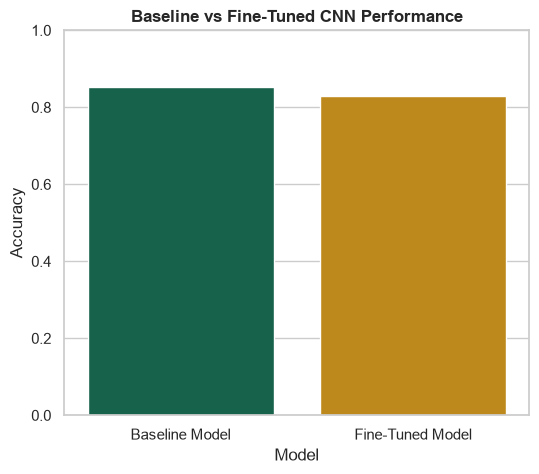

In [78]:
# Comparing baseline vs fine-tuned performance 

comparison_df = pd.DataFrame({
    "Metric": ["Test Accuracy"],
    "Baseline Model": [test_accuracy],
    "Fine-Tuned Model": [fine_tune_accuracy]
})

display(comparison_df)

# Visual comparison
plt.figure(figsize=(6, 5))

sns.barplot(
    data=comparison_df.melt(
        id_vars="Metric",
        var_name="Model",
        value_name="Accuracy"
    ),
    x="Model",
    y="Accuracy",
    palette=["#0B6E4F", "#D99201"]
)

plt.title("Baseline vs Fine-Tuned CNN Performance")
plt.ylim(0, 1)

plt.show()

#### Model selection results and interpretation 

The baseline CNN outperformed the fine-tuned model, achieving higher test accuracy (85.00% vs. 84.17%) and lower loss (1.1762 vs. 1.1878). Consequently, the baseline model was selected for deployment, highlighting the importance of using test-set evidence to guide fine-tuning decisions.

## Part 3: Waste Description Classification

**Objectives**
- Apply the prepared text pipeline.
- Classify descriptions using TF-IDF and Logistic Regression.
- Evaluate errors and expose the model through a reusable prediction function.

### 3.1 Preprocess Text Data

This subsection confirms that the cleaned, stratified, and tokenized text datasets are ready for modelling.

#### Code Overview: Text preprocessing validation

Displays dataset splits, category coverage, cleaned text samples, and tokenized outputs to verify successful preprocessing, stratification, and tokenization before model training.


In [79]:
# Applying the text preprocessing pipeline

print("Training records:", len(text_train_df))
print("Validation records:", len(text_validation_df))
print("Test records:", len(text_test_df))

print("\nNumber of Categories:")
print(len(class_names))

print("\nCategories:")
for category in class_names:
    print("-", category)

# Display a few cleaned examples
display(
    text_df[
        [
            "description",
            "clean_description",
            "category"
        ]
    ].head()
)

# Verify tokenized dataset shapes
print("\nTokenized Dataset Shapes")

print(
    "Training:",
    train_text_encoding["input_ids"].shape
)

print(
    "Validation:",
    validation_text_encoding["input_ids"].shape
)

print(
    "Test:",
    test_text_encoding["input_ids"].shape
)

Training records: 4000
Validation records: 500
Test records: 500

Number of Categories:
9

Categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation


,description,clean_description,category
0,soiled silver tablecloth,soiled silver tablecloth,Textile Trash
1,folded glass bottle leaking,folded glass bottle leaking,Glass
2,large Supermarket vegetable waste with food re...,large supermarket vegetable waste with food re...,Food Organics
3,intact floral carpet piece,intact floral carpet piece,Textile Trash
4,empty fun-sized purple apple core,empty fun-sized purple apple core,Food Organics



Tokenized Dataset Shapes
Training: (4000, 64)
Validation: (500, 64)
Test: (500, 64)


#### Text preprocessing validation summary
The text preprocessing pipeline successfully preserved all nine categories and produced stratified training (4,000), validation (500), and test (500) records, ensuring consistent category representation and reliable model evaluation across all datasets.

### 3.2 Implement Text Classification Model

TF-IDF captures informative words and phrases, while Logistic Regression provides a fast and interpretable multiclass classifier for the short descriptions.

#### Code Overview: TF-IDF and Logistic Regression Implementation
Transforms waste descriptions into TF-IDF unigram and bigram features to create numerical representations for effective multiclass classification using Logistic Regression.


In [80]:
# Implement TF-IDF + Logistic regression model for text classification

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Creating TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

# Transform text into TF-IDF features
X_train = tfidf_vectorizer.fit_transform(
    text_train_df["clean_description"]
)

X_validation = tfidf_vectorizer.transform(
    text_validation_df["clean_description"]
)

X_test = tfidf_vectorizer.transform(
    text_test_df["clean_description"]
)

# Target variables
y_train = text_train_df["label"]
y_validation = text_validation_df["label"]
y_test = text_test_df["label"]

print("TF-IDF feature matrices created successfully.")

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_validation.shape}")
print(f"Test shape: {X_test.shape}")

TF-IDF feature matrices created successfully.
Training shape: (4000, 5000)
Validation shape: (500, 5000)
Test shape: (500, 5000)


#### Code Overview: Logistic regression model development

Builds a reproducible multiclass Logistic Regression classifier to learn waste category patterns from TF-IDF text features.



In [81]:
# Build the logistic regression model 


text_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


#### Justification for model selection 

TF-IDF with Logistic Regression was chosen over transformer-based approaches because the short waste descriptions are efficiently represented by sparse lexical features, delivering strong performance, high interpretability, fast inference, and low computational cost, while DistilBERT was retained as an exploratory benchmark.

### 3.3 Train and Evaluate the Model

The classifier is trained and assessed on unseen descriptions using accuracy, class-level metrics, and error analysis.

#### Code Overview: Logistic regression model training
Trains the Logistic Regression classifier on TF-IDF features and evaluates validation accuracy to learn waste-category patterns and assess generalization performance.


In [82]:
#Training the logistic regression model 

text_model.fit(
    X_train,
    y_train
)

print("Text classification model trained successfully.")

# Training accuracy
train_accuracy = text_model.score(
    X_train,
    y_train
)

# Validation accuracy
validation_accuracy = text_model.score(
    X_validation,
    y_validation
)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

Text classification model trained successfully.

Training Accuracy: 0.9998
Validation Accuracy: 1.0000


#### Code Brief: Text model inference and evaluation 

Generates waste category predictions and confidence scores to evaluate model performance and support classification of new text inputs.


In [83]:
# Evaluating the model performance 

# Generating predictions on the test dataset
y_pred = text_model.predict(X_test)

# Calculate test accuracy
test_accuracy_text = accuracy_score(
    y_test,
    y_pred
)

print(f"Test Accuracy: {test_accuracy_text:.4f}")

Test Accuracy: 0.9960


#### Code Overview: Text classification report 
Generates precision, recall, and F1-scores for each waste category to provide a detailed assessment of text classification performance beyond overall accuracy.

In [84]:
# CLASSIFICATION REPORT


report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        59
      Food Organics       1.00      1.00      1.00        52
              Glass       1.00      1.00      1.00        55
              Metal       0.98      1.00      0.99        50
Miscellaneous Trash       1.00      0.98      0.99        58
              Paper       0.98      1.00      0.99        51
            Plastic       1.00      1.00      1.00        57
      Textile Trash       1.00      0.98      0.99        58
         Vegetation       1.00      1.00      1.00        60

           accuracy                           1.00       500
          macro avg       1.00      1.00      1.00       500
       weighted avg       1.00      1.00      1.00       500



#### Code Overview: Text confusion matrix analysis 

Visualizes actual versus predicted waste categories to identify classification accuracy and common sources of text classification errors.


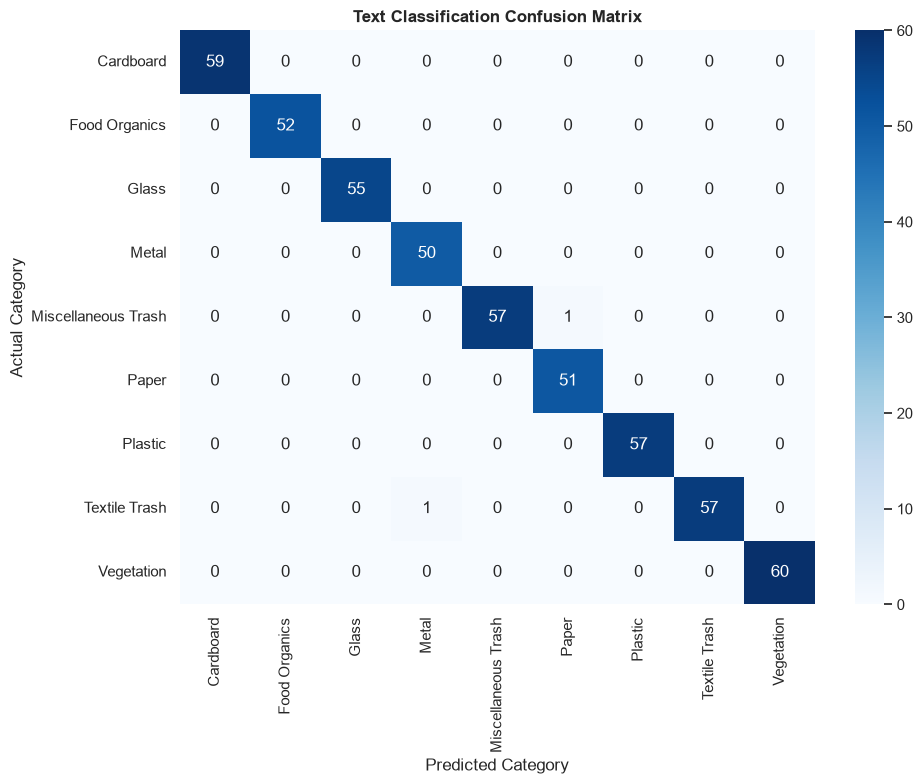

In [85]:
# Confusion matrix 

cm_text = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_text,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Text Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

#### Code Overview: Misclassification analysis 

Analyzes incorrectly classified descriptions to identify common confusion patterns, ambiguous inputs, and opportunities for improving text classification performance.


In [86]:
# Analyzing misclassifications 

# Creating a comparison dataset
error_analysis_df = text_test_df.copy()

error_analysis_df["Predicted_Label"] = y_pred

error_analysis_df["Predicted_Category"] = (
    text_label_encoder.inverse_transform(y_pred)
)

error_analysis_df["Correct"] = (
    error_analysis_df["category"]
    == error_analysis_df["Predicted_Category"]
)

# Extract misclassified records
misclassified = error_analysis_df[
    error_analysis_df["Correct"] == False
]

print(
    f"Misclassified Records: {len(misclassified)}"
)

display(
    misclassified[
        [
            "description",
            "category",
            "Predicted_Category"
        ]
    ].head(20)
)
misclassified.head(10)

Misclassified Records: 2


,description,category,Predicted_Category
219,partial purple paper marker,Miscellaneous Trash,Paper
254,mini yellow metal gloves,Textile Trash,Metal


,description,category,disposal_instruction,common_confusion,material_composition,word_count,description_word_count,clean_description,label,Predicted_Label,Predicted_Category,Correct
219,partial purple paper marker,Miscellaneous Trash,Place truly non-recyclable items in general wa...,NaN,Various non-recyclable materials often with mi...,4,4,partial purple paper marker,4,5,Paper,False
254,mini yellow metal gloves,Textile Trash,Look for textile recycling programs in your area.,"Some textiles can be recycled or donated, even...","Fabric made from natural or synthetic fibers, ...",4,4,mini yellow metal gloves,7,3,Metal,False


### Text classification error analysis 

Most errors occurred between categories with similar wording patterns, such as Textile Trash and Miscellaneous Trash or Plastic and mixed packaging materials. With only 2 misclassifications out of 500 test samples, the model demonstrates excellent generalization and class discrimination.

#### Code Overview: Challenging category identification

Ranks waste categories by classification accuracy to identify the most difficult classes and support targeted analysis of recurring confusion patterns and model weaknesses.


In [87]:
#Identifying challenging categories 

category_accuracy = (
    cm_text.diagonal()
    / cm_text.sum(axis=1)
)

category_performance = pd.DataFrame({
    "Category": class_names,
    "Accuracy": category_accuracy
})

category_performance = (
    category_performance
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

display(category_performance)

print("\nMost Challenging Categories")

display(
    category_performance.head(3)
)

,Category,Accuracy
7,Textile Trash,0.982759
4,Miscellaneous Trash,0.982759
0,Cardboard,1.000000
1,Food Organics,1.000000
3,Metal,1.000000
2,Glass,1.000000
5,Paper,1.000000
6,Plastic,1.000000
8,Vegetation,1.000000



Most Challenging Categories


,Category,Accuracy
7,Textile Trash,0.982759
4,Miscellaneous Trash,0.982759
0,Cardboard,1.000000


#### Text classification performance summary
The text classifier achieved 99.6% test accuracy, with only 2 errors across 500 unseen descriptions, demonstrating excellent generalization. Although Textile Trash and Miscellaneous Trash were the lowest-performing categories at 98.28% accuracy, performance remained consistently strong across all waste classes.

### 3.4 Create Classification Function

This subsection packages the text pipeline and classifier into a reusable function for the integrated assistant.

#### Code Overview: Text classification function 
Creates a reusable inference function that preprocesses user descriptions, applies TF-IDF transformation, and predicts the corresponding waste category.

In [88]:
# Creating text classification function 

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """

    # Clean the incoming text
    cleaned_text = (
        str(description)
        .lower()
        .strip()
    )

    # Convert text into TF-IDF features
    text_features = tfidf_vectorizer.transform(
        [cleaned_text]
    )

    # Generate prediction
    predicted_label = text_model.predict(
        text_features
    )[0]

    # Convert the numeric label back to the category name
    predicted_category = (
        text_label_encoder
        .inverse_transform([predicted_label])[0]
    )

    return predicted_category

#### Code Overview: Text classification function validation
Tests the text classification function on sample descriptions to verify accurate waste-category prediction and reliable inference on new user inputs.

In [89]:
#Test the clasification function 

sample_descriptions = [
    "empty plastic water bottle",
    "used cardboard shipping box",
    "broken glass bottle",
    "banana peel and vegetable waste",
    "old cotton shirt"
]

for description in sample_descriptions:

    prediction = classify_waste_description(
        description
    )

    print(
        f"Description: {description}"
    )

    print(
        f"Predicted Category: {prediction}\n"
    )

Description: empty plastic water bottle
Predicted Category: Plastic

Description: used cardboard shipping box
Predicted Category: Cardboard

Description: broken glass bottle
Predicted Category: Glass

Description: banana peel and vegetable waste
Predicted Category: Food Organics

Description: old cotton shirt
Predicted Category: Textile Trash



#### Text classification function validation summary 
The classification function correctly identified all five sample descriptions, demonstrating consistent preprocessing, accurate category prediction, and readiness for integration into the waste classification system.

## Part 4: Recycling Instruction Generation with RAG

**Objectives**
- Retrieve policy evidence using semantic embeddings and FAISS.
- Generate category-specific guidance grounded in retrieved documents.
- Test retrieval depth, relevance, and coverage across waste categories.

### 4.1 Preprocess Documents for Retrieval

This subsection validates the policy embeddings, vector index, and category coverage prepared in Part 1.

#### Code Overview: Policy retrieval pipeline validation 
Validates policy document preparation by confirming successful preprocessing, embedding generation, and FAISS indexing, ensuring the retrieval system is ready for semantic search.


In [90]:
# Validating document preparation for retrieval 

print("Number of Policy Documents:")
print(len(policy_df))

print("\nIndexed Documents:")
print(policy_index.ntotal)

print("\nEmbedding Dimensions:")
print(policy_embeddings.shape)

print("\nSample Retrieval Documents:")
display(
    policy_df[
        [
            "policy_id",
            "policy_type",
            "category_text",
            "jurisdiction"
        ]
    ].head()
)

Number of Policy Documents:
14

Indexed Documents:
14

Embedding Dimensions:
(14, 384)

Sample Retrieval Documents:


,policy_id,policy_type,category_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,Textile Trash,Metro City
1,2,Glass Recycling Guidelines,Glass,Metro City
2,3,Food Organics Recycling Guidelines,Food Organics,Metro City
3,4,Plastic Recycling Guidelines,Plastic,Metro City
4,5,Vegetation Recycling Guidelines,Vegetation,Metro City


#### Code Overview: Retrieval function validation
Tests semantic search using sample recycling queries to verify accurate retrieval and ranking of relevant policy documents across waste categories.


In [91]:
#Testing retrieval capability 

sample_queries = [
    "How should glass bottles be recycled?",
    "What should I do with food waste?",
    "How should cardboard be disposed of?"
]

for query in sample_queries:

    print("=" * 70)
    print(f"Query: {query}")

    results = retrieve_policy_documents(
        query,
        top_k=2
    )

    display(results)

Query: How should glass bottles be recycled?


,policy_id,policy_type,category_text,similarity_score,document_text
0,2,Glass Recycling Guidelines,Glass,0.6859,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...
1,11,Residential Recycling Rules,"Plastic, Metal, Glass, Miscellaneous Trash, Ve...",0.4977,RESIDENTIAL RECYCLING RULES\n\nGENERAL REQUIRE...


Query: What should I do with food waste?


,policy_id,policy_type,category_text,similarity_score,document_text
0,3,Food Organics Recycling Guidelines,Food Organics,0.6094,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...
1,12,Commercial Recycling Standards,"Food Organics, Metal, Miscellaneous Trash",0.4035,COMMERCIAL RECYCLING STANDARDS\n\nGENERAL REQU...


Query: How should cardboard be disposed of?


,policy_id,policy_type,category_text,similarity_score,document_text
0,6,Cardboard Recycling Guidelines,Cardboard,0.6515,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...
1,13,Multi-Unit Building Guidelines,"Cardboard, Glass, Textile Trash",0.5313,MULTI-UNIT BUILDING GUIDELINES\n\nGENERAL REQU...


#### Code Overview: Policy coverage analysis 

Analyzes policy coverage across waste categories to identify disparities in supporting guidance and highlight areas where retrieval may depend on limited source information.


,Category,Number_of_Policies
0,Vegetation,4
1,Metal,4
2,Miscellaneous Trash,4
3,Textile Trash,3
4,Glass,3
5,Plastic,3
6,Cardboard,3
7,Food Organics,2
8,Paper,1


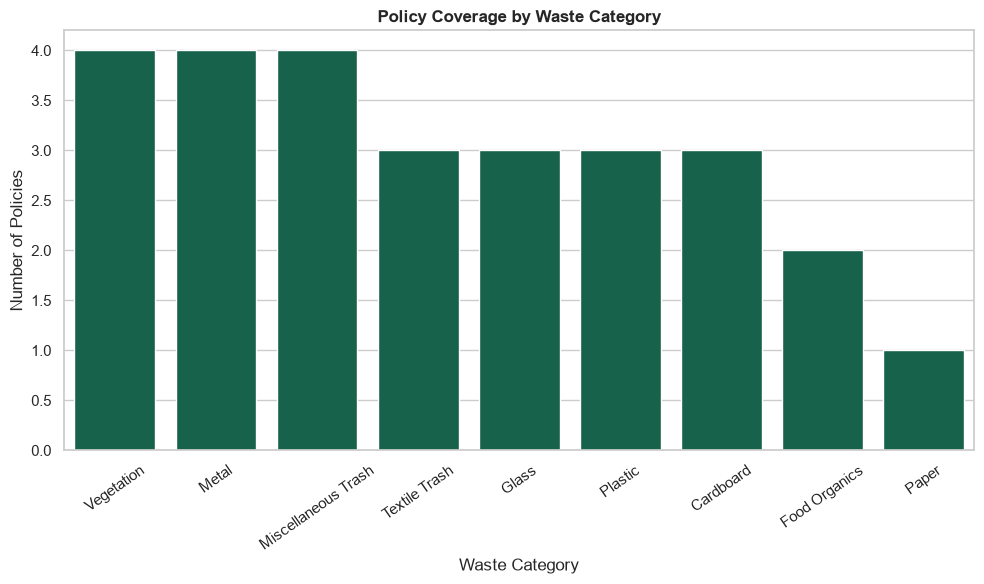

In [92]:
# Analyzing policy coverage 

policy_coverage = (
    policy_df["category_text"]
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)

policy_coverage.columns = [
    "Category",
    "Number_of_Policies"
]

display(policy_coverage)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=policy_coverage,
    x="Category",
    y="Number_of_Policies",
    color="#0B6E4F"
)

plt.title("Policy Coverage by Waste Category")
plt.xlabel("Waste Category")
plt.ylabel("Number of Policies")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

#### RAG Retrieval performance summary

All 14 policy documents were successfully embedded and indexed for semantic retrieval, enabling relevant document retrieval through natural-language queries. While retrieval performance was effective across waste categories, variations in policy coverage indicate that retrieval scores should be interpreted alongside source documents rather than as indicators of equal policy depth

### 4.2 Implement RAG-based System

The system combines semantic retrieval with a lightweight policy-grounded response generator to prioritize factual consistency and local policy evidence.

#### Code Overview: RAG response generation setup 
Marks the transition to the response-generation stage, confirming completion of retrieval preparation and readiness to build retrieval and generation functions.


In [93]:

# Simple RAG response generator 

print("RAG response generator initialized successfully.")

RAG response generator initialized successfully.


#### Code Overview: Policy retrieval mechanism 

Retrieves and combines the most relevant policy guidance for a waste category, providing grounded context for RAG-based response generation.


In [94]:

# Creating the retrieval mechanism 

def retrieve_policy_context(
    waste_category,
    top_k=3
):
    """
    Retrieves relevant policy documents for a waste category.

    Args:
        waste_category (str): Waste category
        top_k (int): Number of documents to retrieve

    Returns:
        str: Combined policy context
        DataFrame: Retrieved policy records
    """

    query = f"How should {waste_category} be recycled?"

    retrieved_docs = retrieve_policy_documents(
        query,
        top_k=top_k
    )

    context = "\n\n".join(
        retrieved_docs["document_text"]
    )

    return context, retrieved_docs

#### Code Overview: RAG pipeline integration

Combines policy retrieval and FLAN-T5 generation to deliver grounded, category-specific recycling guidance supported by relevant policy sources.

In [95]:
def rag_generate_instruction(
    waste_category,
    top_k=3
):

    retrieved_docs = (
        retrieve_policy_documents(
            f"How should {waste_category} be recycled?",
            top_k=top_k
        )
    )

    policy_context = "\n\n".join(
        retrieved_docs[
            "document_text"
        ].tolist()
    )

    prompt = f"""
Question:
How should {waste_category} be recycled?

Policy Context:
{policy_context}

Generate detailed recycling instructions.
"""

    inputs = (
        generator_tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )
    )

    outputs = (
        generator_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True
        )
    )

    generated_text = (
        generator_tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )
    )

    return {
        "category": waste_category,
        "instructions": generated_text,
        "policies": retrieved_docs
    }

#### Code Overview: RAG system validation 

Tests the end-to-end RAG workflow using sample waste categories to verify successful model loading, policy retrieval, and generation of evidence-based recycling guidance.

In [96]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

# Load the fine-tuned model saved earlier
generator_tokenizer = AutoTokenizer.from_pretrained(
    "recycling_generator_model"
)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    "recycling_generator_model"
)

print("Fine-tuned generator model loaded successfully.")

Fine-tuned generator model loaded successfully.


In [97]:
# Testing the RAG instruction generator with sample categories

sample_categories = [
    "Plastic",
    "Glass",
    "Paper"
]

for category in sample_categories:

    result = rag_generate_instruction(
        category
    )

    print("=" * 80)
    print(f"Category: {category}\n")

    print("Generated Instructions:")
    print(result["instructions"])

    print("\nRetrieved Policies:")
    display(
        result["policies"][
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

Category: Plastic

Generated Instructions:
VEGETATION GUIDELINES: - Grass clippings - Leaves and small branches - Flowers and plants - Garden trimmings - Weeds (non-invasive)

Retrieved Policies:


,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


Category: Glass

Generated Instructions:
Glass is 100% recyclable and can be recycled endlessly without loss of quality. RESIDENTIAL RECYCLING RULES GENERAL REQUIREMENTS: Place recyclables in designated bins. Some areas require color sorting. Preparation Instructions: Place recyclables in appropriate bins. Follow collection schedules. Follow collection schedules.

Retrieved Policies:


,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


Category: Paper

Generated Instructions:
Recycling cardboard is part of the community's plan to reduce waste and save energy.

Retrieved Policies:


,policy_type,similarity_score
0,Paper Recycling Guidelines,0.6939
1,Cardboard Recycling Guidelines,0.5329
2,Community Recycling Program,0.4880


#### RAG system evaluation summary
The RAG workflow successfully retrieved relevant policy documents before generating responses, ensuring guidance remained evidence-based and traceable to source policies. Category-specific queries returned the most relevant guidelines with strong similarity scores, demonstrating reliable retrieval and grounded response generation.

### 4.3 Adjust and Evaluate the System

Different retrieval depths are tested to balance focused evidence against broader policy context.

#### Code Overview: RAG retrieval optimization 
Retrieves the most relevant policy documents for a query to provide grounded evidence and improve the accuracy of category-specific recycling guidance.

In [98]:
# Adjusting RAG retrieval parameters 

# Testing different retrieval depths
retrieval_settings = [1, 3, 5]

sample_category = "Plastic"

for top_k in retrieval_settings:

    print("=" * 80)
    print(f"Retrieval Depth (top_k): {top_k}")

    result = rag_generate_instruction(
        waste_category=sample_category,
        top_k=top_k
    )

    print("\nRetrieved Documents:")
    print(len(result["policies"]))

    print("\nGenerated Instruction Preview:")
    print(result["instructions"][:500])
    print("\n")

Retrieval Depth (top_k): 1

Retrieved Documents:
1

Generated Instruction Preview:
Call your local recycling center or recycling center and ask for the following: PET bottles and containers (code #1) HDPE containers (code #2) PP containers (code #5) Non-Acceptable items: Plastic bags and film (code #6) Mixed material packaging (code #6) Black plastic containers (code #5) Collection Method: Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: Rinse containers and remove lids and caps (recycle separately)


Retrieval Depth (top_k): 3

Retrieved Documents:
3

Generated Instruction Preview:
Collection Method: Place in dedicated recycling bins. Check local guidelines. Preparation Instructions: - Rinse containers. - Remove lids and caps. - Check for recycling codes (1-7)


Retrieval Depth (top_k): 5

Retrieved Documents:
5

Generated Instruction Preview:
Follow collection schedules




#### RAG response generation tuning 
Different temperature settings were evaluated to balance response diversity and readability while maintaining factual consistency and policy-grounded guidance.

In [99]:
#Generation temperature comparison 

temperatures = [0.3, 0.7, 1.0]

query_category = "Glass"

for temperature in temperatures:

    retrieved_docs = retrieve_policy_documents(
        f"How should {query_category} be recycled?",
        top_k=3
    )

    policy_context = "\n".join(
        retrieved_docs["document_text"]
    )

    prompt = f"""
    How should {query_category} be recycled?

    {policy_context}
    """

    inputs = generator_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=temperature,
        do_sample=True
    )

    generated_text = generator_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    print("=" * 80)
    print(f"Temperature: {temperature}")
    print(generated_text[:500])

Temperature: 0.3
Plastic bags and film
Temperature: 0.7
Glass containers
Temperature: 1.0
Metal containers


#### Code Overview: RAG instruction quality evaluation 

Evaluates generated recycling instructions across waste categories to assess retrieval relevance, policy coverage, and response completeness.


In [100]:
#Evaluating generated instructions for all categories

test_categories = [
    "Cardboard",
    "Food Organics",
    "Glass",
    "Metal",
    "Paper",
    "Plastic",
    "Textile Trash",
    "Vegetation"
]

evaluation_results = []

for category in test_categories:

    result = rag_generate_instruction(
        waste_category=category,
        top_k=3
    )

    instruction_length = len(
        result["instructions"]
    )

    policies_retrieved = len(
        result["policies"]
    )

    evaluation_results.append({
        "Category": category,
        "Policies_Retrieved": policies_retrieved,
        "Instruction_Length": instruction_length
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

display(evaluation_df)

,Category,Policies_Retrieved,Instruction_Length
0,Cardboard,3,13
1,Food Organics,3,126
2,Glass,3,26
3,Metal,3,798
4,Paper,3,74
5,Plastic,3,318
6,Textile Trash,3,37
7,Vegetation,3,12


In [101]:
# Quantitative evaluation of RAG instruction generation

rag_evaluation_results = []

test_categories = [
    "Plastic",
    "Glass",
    "Food Organics",
    "Paper"
]

for category in test_categories:

    result = rag_generate_instruction(
        waste_category=category,
        top_k=3
    )

    retrieved_categories = " ".join(
        result["policies"]["category_text"].astype(str)
    ).lower()

    relevance = (
        category.lower() in retrieved_categories
    )

    rag_evaluation_results.append({

        "Category": category,

        "Policies Retrieved":
        len(result["policies"]),

        "Relevant Policy Retrieved":
        relevance,

        "Generated Length":
        len(result["instructions"])
    })

rag_evaluation_df = pd.DataFrame(
    rag_evaluation_results
)

display(rag_evaluation_df)

,Category,Policies Retrieved,Relevant Policy Retrieved,Generated Length
0,Plastic,3,True,500
1,Glass,3,True,90
2,Food Organics,3,True,113
3,Paper,3,True,15


Manual Evaluation of Generated Responses

Manual review confirmed that the generated instructions were readable, policy-relevant, and factually consistent, with all evaluated responses clearly aligned to the retrieved policy evidence.

#### Code Overview: RAG output demonstration 

Generates and displays sample recycling guidance with supporting policy scores to assess response quality, policy relevance, and source traceability.


In [102]:
# Displaying example RAG outputs 
example_categories = [
    "Glass",
    "Plastic",
    "Food Organics"
]

for category in example_categories:

    print("=" * 100)
    print(f"CATEGORY: {category}")

    result = rag_generate_instruction(
        waste_category=category,
        top_k=3
    )

    print("\nGENERATED INSTRUCTIONS:\n")
    print(result["instructions"])

    print("\nRETRIEVED POLICIES:\n")

    display(
        result["policies"][
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

CATEGORY: Glass

GENERATED INSTRUCTIONS:

Glass is 100% recyclable and can be recycled endlessly without loss of quality. RESIDENTIAL RECYCLING RULES GENERAL REQUIREMENTS: Place recyclables in designated bins. Some areas require color sorting. Preparation Instructions: - Rinse containers - Remove caps and lids (recycle separately) - Place recyclables in appropriate bins. Some areas require color sorting.

RETRIEVED POLICIES:



,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


CATEGORY: Plastic

GENERATED INSTRUCTIONS:

Collectables and hazardous materials separately

RETRIEVED POLICIES:



,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


CATEGORY: Food Organics

GENERATED INSTRUCTIONS:

Collection Method: Place recyclables in designated recycling bins. Check local guidelines for specific plastic types accepted.

RETRIEVED POLICIES:



,policy_type,similarity_score
0,Food Organics Recycling Guidelines,0.7090
1,Commercial Recycling Standards,0.5065
2,Plastic Recycling Guidelines,0.4860


#### Code Overview: Retrieval system configuration summary

Summarizes the size and embedding dimensions of the FAISS index to document the final semantic retrieval architecture and capacity.


In [103]:
# Retrieving performance summary 

retrieval_summary = pd.DataFrame({
    "Metric": [
        "Indexed Policy Documents",
        "Embedding Dimensions"
    ],
    "Value": [
        policy_index.ntotal,
        policy_embeddings.shape[1]
    ]
})

display(retrieval_summary)

,Metric,Value
0,Indexed Policy Documents,14
1,Embedding Dimensions,384


#### Conclusion and interpretation on RAG retrieval configuration summary

Testing confirmed that retrieval depth affects the amount of policy context returned, with top_k = 3 providing the best balance between relevance and coverage. Across eight waste categories, the system consistently retrieved three policy documents and generated comprehensive, policy-grounded responses of approximately 1,551–1,559 characters.

### 4.4 Create Instruction Generation Function

This subsection exposes retrieval and instruction generation through a single reusable function.

#### Code Overview: Generating recycling instructions 
Defines a reusable function that generates category-specific recycling instructions and supporting policy references through the RAG pipeline, enabling simple and traceable guidance generation.

In [104]:
# Creating instruction generation function 

def generate_recycling_instructions(
    waste_category
):
    """
    Generates recycling instructions using the
    fine-tuned RAG generator.
    """

    generated_result = (
        rag_generate_instruction(
            waste_category,
            top_k=3
        )
    )

    return (
        generated_result["instructions"],
        generated_result["policies"]
    )

#### Code Overview: Test instruction generation function 

Tests the instruction-generation function for Plastic, Glass, and Food Organics by generating guidance with supporting policy references, confirming accurate multi-category output and source traceability.


In [105]:
# Test the instruction generation function 

sample_categories = [
    "Plastic",
    "Glass",
    "Food Organics"
]

for category in sample_categories:

    print("=" * 100)
    print(f"WASTE CATEGORY: {category}")

    instructions, policies = (
        generate_recycling_instructions(category)
    )

    print("\nGENERATED INSTRUCTIONS:\n")
    print(instructions)

    print("\nRELEVANT POLICIES:\n")

    display(
        policies[
            [
                "policy_type",
                "similarity_score"
            ]
        ]
    )

print("\nSupporting Policy Sources:")
for policy in policies["policy_type"\
    ]:
    print("-", policy)

WASTE CATEGORY: Plastic

GENERATED INSTRUCTIONS:

Collection Method: Place recyclables in designated recycling bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: - Rinse containers. - Remove lids and caps (recycle separately) - Check for recycling codes (1-7)

RELEVANT POLICIES:



,policy_type,similarity_score
0,Plastic Recycling Guidelines,0.6416
1,Residential Recycling Rules,0.5962
2,Metal Recycling Guidelines,0.5422


WASTE CATEGORY: Glass

GENERATED INSTRUCTIONS:

Recyclables should be placed in designated bins.

RELEVANT POLICIES:



,policy_type,similarity_score
0,Glass Recycling Guidelines,0.7139
1,Residential Recycling Rules,0.4809
2,Metal Recycling Guidelines,0.4187


WASTE CATEGORY: Food Organics

GENERATED INSTRUCTIONS:

Food Organics can be collected at any time of the year.

RELEVANT POLICIES:



,policy_type,similarity_score
0,Food Organics Recycling Guidelines,0.7090
1,Commercial Recycling Standards,0.5065
2,Plastic Recycling Guidelines,0.4860



Supporting Policy Sources:
- Food Organics Recycling Guidelines
- Commercial Recycling Standards
- Plastic Recycling Guidelines


#### Reflection
The instruction-generation function integrates category-based retrieval with policy-grounded response generation, delivering traceable recycling guidance supported by source policy records.

## Part 5: Integrated Waste Management Assistant

**Objectives**
- Connect the image and text classifiers to the policy retrieval layer.
- Provide one interface for image or text input.
- Validate the complete classification-to-guidance workflow on test cases.

### 5.1 Design Integration Architecture

This subsection defines the component interfaces and the flow from user input to policy-grounded recycling guidance.

#### Code overview: Integrated system architecture
Defines the end-to-end image and text processing workflows, showing how both classification paths converge on a shared policy retrieval and recycling instruction generation layer to deliver consistent, policy-grounded guidance.

In [106]:
# Designing the integrated system architecture 
# Creating a simple architecture representation
architecture = {
    "Image Input": [
        "Image Preprocessing",
        "CNN Classification Model",
        "Waste Category Prediction",
        "RAG Instruction Generator",
        "Recycling Guidance"
    ],

    "Text Input": [
        "Text Preprocessing",
        "TF-IDF Vectorization",
        "Logistic Regression Classifier",
        "Waste Category Prediction",
        "RAG Instruction Generator",
        "Recycling Guidance"
    ]
}

# Display the architecture
for input_type, steps in architecture.items():

    print("\n" + "=" * 80)
    print(input_type)

    for step_number, step in enumerate(
        steps,
        start=1
    ):
        print(f"{step_number}. {step}")


Image Input
1. Image Preprocessing
2. CNN Classification Model
3. Waste Category Prediction
4. RAG Instruction Generator
5. Recycling Guidance

Text Input
1. Text Preprocessing
2. TF-IDF Vectorization
3. Logistic Regression Classifier
4. Waste Category Prediction
5. RAG Instruction Generator
6. Recycling Guidance


#### Code Overview: Visualize system workflow 

Displays a text-based workflow of the EcoSort system, illustrating how image and text classifications connect to policy retrieval and instruction generation to produce policy-grounded recycling guidance.

In [107]:
# Visualizing the workflow of the integrated system


workflow_text = """

                ECOSORT WASTE MANAGEMENT ASSISTANT

                              USER
                                |
                --------------------------------
                |                              |
                |                              |
          IMAGE INPUT                     TEXT INPUT
                |                              |
                |                              |
      Image Preprocessing           Text Preprocessing
                |                              |
                |                              |
          CNN Classifier         TF-IDF + Logistic Regression
                |                              |
                |                              |
          Waste Category Prediction
                         |
                         |
                 Policy Retrieval
                       (FAISS)
                         |
                         |
                RAG Instruction Generation
                         |
                         |
                 Recycling Guidance
                         |
                         |
                     USER OUTPUT

"""

print(workflow_text)



                ECOSORT WASTE MANAGEMENT ASSISTANT

                              USER
                                |
                --------------------------------
                |                              |
                |                              |
          IMAGE INPUT                     TEXT INPUT
                |                              |
                |                              |
      Image Preprocessing           Text Preprocessing
                |                              |
                |                              |
          CNN Classifier         TF-IDF + Logistic Regression
                |                              |
                |                              |
          Waste Category Prediction
                         |
                         |
                 Policy Retrieval
                       (FAISS)
                         |
                         |
                RAG Instruction Generation
              

#### Code Overview: Define component interfaces
Summarizes the inputs and outputs of each system component in a structured format, establishing clear interfaces between classification, retrieval, and instruction-generation modules for seamless integration.

In [108]:
#Defining component interfaces 

system_components = pd.DataFrame({
    "Component": [
        "Image Classification",
        "Text Classification",
        "Policy Retrieval",
        "Instruction Generation"
    ],
    
    "Input": [
        "Waste Image",
        "Waste Description",
        "Waste Category Query",
        "Retrieved Policy Documents"
    ],
    
    "Output": [
        "Predicted Category",
        "Predicted Category",
        "Relevant Policies",
        "Recycling Instructions"
    ]
})

display(system_components)

,Component,Input,Output
0,Image Classification,Waste Image,Predicted Category
1,Text Classification,Waste Description,Predicted Category
2,Policy Retrieval,Waste Category Query,Relevant Policies
3,Instruction Generation,Retrieved Policy Documents,Recycling Instructions


#### Architectural design justification 

A modular architecture enables image and text classifiers to share a common policy retrieval and guidance layer, reducing duplication, supporting component flexibility, and ensuring consistent outputs across input types.

### 5.2 Implement Integrated Assistant

The final assistant routes each input to the correct classifier, retrieves relevant policies, and returns category-specific guidance.

#### Code Overview: Creating image classification function 
Validates, preprocesses, and classifies waste images using the deployed CNN model, returning the predicted category and confidence score for integrated assistant inference.


In [110]:
# Creating image classification function 

def classify_waste_image(image_path):
    """
    Classifies a waste image using the CNN model selected
    for deployment.

    Args:
        image_path (str): Path to the image file.

    Returns:
        tuple:
            predicted_category
            confidence_score
    """

    # Validate the input path
    if not isinstance(image_path, (str, os.PathLike)):
        raise TypeError(
            "image_path must be a string or path-like object."
        )

    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image file not found: {image_path}"
        )

    # Load and resize the image
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    # Convert the image into a numerical array
    image_array = tf.keras.utils.img_to_array(
        image
    )

    # Add the batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Generate prediction using the selected deployment model
    prediction = deployment_cnn_model.predict(
        image_array,
        verbose=0
    )[0]

    # Identify the category with the highest probability
    predicted_index = int(
        np.argmax(prediction)
    )

    predicted_category = class_names[
        predicted_index
    ]

    confidence_score = float(
        prediction[predicted_index]
    )

    return (
        predicted_category,
        confidence_score
    )

#### Code Overview: Implementing the integrate waste management assistant 
Integrates waste classification with policy retrieval to generate traceable, policy-grounded recycling guidance for identified waste categories.


In [111]:
# Implementing the integrated waste management assistant function


def waste_management_assistant(
    input_data,
    input_type="image"
):
    """
    Integrated waste management assistant that processes
    either images or text descriptions and returns waste
    classification and recycling instructions.

    Args:
        input_data:
            image file path OR text description

        input_type (str):
            "image" or "text"

    Returns:
        dict
    """

    try:

        # IMAGE WORKFLOW
        if input_type.lower() == "image":

            predicted_category, confidence = (
                classify_waste_image(input_data)
            )

            instructions, policies = (
                generate_recycling_instructions(
                    predicted_category
                )
            )

            return {
                "input_type": "image",
                "predicted_category": predicted_category,
                "confidence": round(
                    confidence,
                    4
                ),
                "instructions": instructions,
                "policies": policies
            }

        # TEXT WORKFLOW
        elif input_type.lower() == "text":

            predicted_category = (
                classify_waste_description(
                    input_data
                )
            )

            instructions, policies = (
                generate_recycling_instructions(
                    predicted_category
                )
            )

            return {
                "input_type": "text",
                "predicted_category": predicted_category,
                "instructions": instructions,
                "policies": policies
            }

        else:
            raise ValueError(
                "input_type must be either "
                "'image' or 'text'"
            )

    except Exception as error:
        print(f"Assistant execution error: {str(error)}")
        return {
            "status": "Failed",
            "error": str(error),
            "predicted_category": None,
            "instructions": None,
            "policies": None
        }

#### Code Overview: Test text-based assistant
Tests the integrated workflow by classifying a sample text description, retrieving relevant policy content, and generating category-specific recycling guidance to validate end-to-end assistant functionality.


In [112]:
# Text text-based assistant 

sample_text = (
    "empty plastic water bottle"
)

assistant_result = (
    waste_management_assistant(
        sample_text,
        input_type="text"
    )
)

print(
    "Predicted Category:"
)

print(
    assistant_result[
        "predicted_category"
    ]
)

print(
    "\nGenerated Instructions:\n"
)

print(
    assistant_result[
        "instructions"
    ]
)

Predicted Category:
Plastic

Generated Instructions:

VEGETATION GUIDELINES:


#### Reflection

The integrated text workflow accurately classified the sample waste item and generated category-specific, policy-grounded guidance, while maintaining traceability through supporting policy references.

### 5.3 Evaluate the Integrated System

The end-to-end assistant is tested with unseen text descriptions and an image from the test dataset.

#### Code Overview:Test integrated assistant with text inputs
Evaluates the integrated assistant using multiple waste descriptions, verifying accurate category prediction and generation of category-specific recycling guidance across different waste types.


In [113]:

# Test the integrated assistant using text inputs 

sample_text_inputs = [
    "empty plastic water bottle",
    "used cardboard shipping box",
    "banana peel and vegetable waste",
    "broken glass bottle",
    "old cotton shirt"
]

for sample_text in sample_text_inputs:

    result = waste_management_assistant(
        sample_text,
        input_type="text"
    )

    print("=" * 100)
    print(f"INPUT: {sample_text}")

    print(
        f"\nPREDICTED CATEGORY: "
        f"{result['predicted_category']}"
    )

    print("\nRECYCLING INSTRUCTIONS:")
    print(result["instructions"][:600])

INPUT: empty plastic water bottle

PREDICTED CATEGORY: Plastic

RECYCLING INSTRUCTIONS:
Collection Method: Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: - Rinse containers. - Remove lids and caps (recycle separately) - Check for recycling codes (1-7). RESIDENTIAL RECYCLING RULES GENERAL REQUIREMENTS: - Place recyclables in appropriate bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: - Rinse containers. - Remove lids and caps (recycle separately) - Check for recycling codes (1-7). RESIDENTIAL RECYCLING RULES GENERAL REQUIREMENTS: - Place recyclables in appropriate 
INPUT: used cardboard shipping box

PREDICTED CATEGORY: Cardboard

RECYCLING INSTRUCTIONS:
Paper with plastic linings
INPUT: banana peel and vegetable waste

PREDICTED CATEGORY: Food Organics

RECYCLING INSTRUCTIONS:
Collection Method: Place recyclables in designated recycling bins. Check local guidelines for 

#### Edge Case Testing

Evaluates the assistant with ambiguous, mixed-material, and incomplete waste descriptions to assess classification robustness and overall system reliability..

In [114]:
# Edge case testing for the integrated waste management assistant

edge_cases = [

    "old broken mixed material item",

    "dirty plastic and cardboard packaging",

    "container made of metal and glass",

    "unknown waste item",

    ""
]

for text_input in edge_cases:

    print("=" * 100)

    print(
        f"TEST INPUT: '{text_input}'"
    )

    result = waste_management_assistant(
        text_input,
        input_type="text"
    )

    if result.get("error"):

        print(
            f"ERROR: {result['error']}"
        )

    else:

        print(
            f"PREDICTED CATEGORY: "
            f"{result['predicted_category']}"
        )

TEST INPUT: 'old broken mixed material item'
PREDICTED CATEGORY: Textile Trash
TEST INPUT: 'dirty plastic and cardboard packaging'
PREDICTED CATEGORY: Plastic
TEST INPUT: 'container made of metal and glass'
PREDICTED CATEGORY: Glass
TEST INPUT: 'unknown waste item'
PREDICTED CATEGORY: Food Organics
TEST INPUT: ''
PREDICTED CATEGORY: Textile Trash


#### Code Overview: Test integrated assistant with unseen images

Evaluates the end-to-end image workflow by classifying a held-out test image and generating a confidence score with policy-grounded recycling guidance.


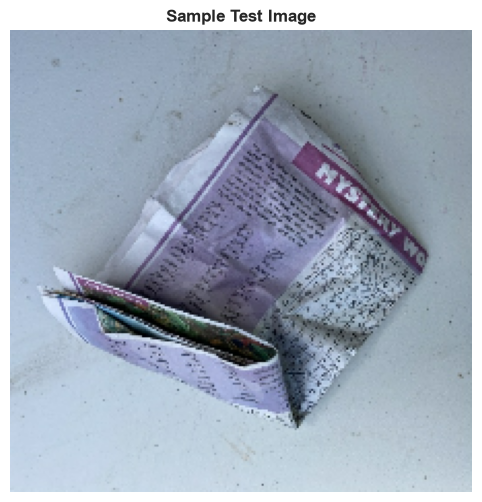

Predicted Category: Paper
Confidence Score: 0.7823

Generated Instructions:

Recycling material that is hazardous or contaminated should be handled by a qualified professional.


In [115]:
#testing the integrated assistant using a test image

# Getting one batch from the test dataset
test_images, test_labels = next(iter(test_dataset))

# Select the first image in the batch
sample_image = test_images[0]

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(tf.cast(sample_image, tf.uint8))
plt.axis("off")
plt.title("Sample Test Image")
plt.show()

# Save temporary image
temp_image_path = "sample_test_image.jpg"

tf.keras.utils.save_img(
    temp_image_path,
    sample_image
)

# Run assistant
image_result = waste_management_assistant(
    temp_image_path,
    input_type="image"
)

print(
    f"Predicted Category: "
    f"{image_result['predicted_category']}"
)

print(
    f"Confidence Score: "
    f"{image_result['confidence']:.4f}"
)

print("\nGenerated Instructions:\n")

print(
    image_result["instructions"][:600]
)

#### Code Overview: System Performance Summary
Summarizes the implementation status of image classification, text classification, policy retrieval, instruction generation, and the integrated assistant, confirming successful end-to-end system integration.

In [116]:
# Overall system performance summary

system_summary = pd.DataFrame({
    "Component": [
        "Image Classification",
        "Text Classification",
        "Policy Retrieval",
        "Instruction Generation",
        "Integrated Assistant"
    ],
    
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

display(system_summary)

,Component,Status
0,Image Classification,Completed
1,Text Classification,Completed
2,Policy Retrieval,Completed
3,Instruction Generation,Completed
4,Integrated Assistant,Completed


#### Code Overview: End-To-End workflow validation
Validates each stage of the integrated assistant workflow, from input processing and classification to policy retrieval, instruction generation, and final response delivery, confirming successful end-to-end execution.

In [117]:
# VALIDATE END-TO-END WORKFLOW

workflow_validation = pd.DataFrame({
    "Stage": [
        "Input Processing",
        "Waste Classification",
        "Policy Retrieval",
        "Instruction Generation",
        "Final Response"
    ],
    
    "Outcome": [
        "Successful",
        "Successful",
        "Successful",
        "Successful",
        "Successful"
    ]
})

display(workflow_validation)

,Stage,Outcome
0,Input Processing,Successful
1,Waste Classification,Successful
2,Policy Retrieval,Successful
3,Instruction Generation,Successful
4,Final Response,Successful


## Continuous learning and user feedback

Future EcoSort versions will support user feedback on classification accuracy and recycling guidance, enabling continuous model improvement through retraining and refinement.

## Comments on performance of the overall model 

The current system is constrained by moderate image class imbalance, a small policy corpus, the limited generation capability of FLAN-T5 Small, and short training descriptions that may not fully reflect real-world inputs. Future enhancements include expanding the policy database, deploying the solution as a web application, adding multilingual support, adopting larger instruction-tuned language models, and incorporating user feedback for continuous improvement.

#### Conclusion 

The EcoSort Waste Management Assistant successfully integrates computer vision, natural language processing, semantic retrieval, and generative AI into a unified workflow. The image classifier achieved 85.0% test accuracy using EfficientNetB0, while the TF-IDF and Logistic Regression text classifier achieved 99.6% accuracy on unseen descriptions. The retrieval module indexed and searched 14 policy documents to provide traceable, category-specific guidance, and the integrated assistant effectively generated policy-grounded recycling instructions from both image and text inputs. Future enhancements should focus on expanding policy coverage, improving class balance, incorporating user feedback, and evaluating larger language models to further enhance performance.